# 02 — Classical ML baselines: oracle-mask material classification

Task: **given a ground-truth instance mask, classify its material (gravel vs sand).**
Classical-ML counterpart of `01` — handcrafted features + shallow estimators instead
of a learned segmenter. Answers: *how far do traditional features take us?*

**Headline (owner preference, literature-backed): SVM-RBF + baseline106-style arm**
(GLCM + HSV + LBP). Extended here to a ~196-d paper-complete set:

| family | dims | source |
|---|---|---|
| color (RGB+HSV+Lab stats) | 27 | masked-pixel moments |
| GLCM | 72 | 6 props x 12 offsets, GPU |
| LBP uniform | 10 | Ojala '02, GPU |
| LTP upper/lower | 20 | Tan & Triggs '10, GPU |
| GLRLM | 28 | Galloway '75 run-length props x 4 dirs |
| Tamura | 18 | coarseness + contrast + directionality hist |
| granulometry | 7 | morphological pattern spectrum |
| fractal dim | 1 | box-counting on edges |
| shape | 13 | Hu moments + geometry |

**Literature basis:** ASCE basaltic-aggregate texture classification; JMMF 2022
gangue/limestone GLCM+LBP+LTP+Tamura -> SVM 96.8%; sedimentary-rock GLCM+SVM ~94%.

**GPU:** GLCM/LBP/LTP/color are batched on RX 7800 XT (torch/ROCm); a torch MLP
joins the estimator bake-off alongside sklearn models.

**Protocol (same discipline as 00/01):** dev = instances from `gold_aug/train` +
`gold/valid`, grouped by clip (`merged_group` from `split_audit.csv`; aug variants
inherit parent group) -> **GroupKFold(4)**; holdout = `gold/test`, evaluated **once**
on the winning config. Viz-first throughout.

## 0. Environment + dataset wiring

In [1]:
# ============================================================
# 0.1 ENV — versions, seed, paths, GPU
# NOTE (WSL/ROCm): torch needs WSL-aware ROCm libs preloaded:
#   LD_PRELOAD=/opt/rocm/lib/libhsa-runtime64.so.1
#   LD_LIBRARY_PATH=/opt/rocm/lib
# ============================================================
import os, sys, json, time, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cv2, yaml
from PIL import Image
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (f1_score, accuracy_score, confusion_matrix,
                             classification_report)
import torch
import torch.nn as nn

SEED = 42
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)
DEV_T = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXP_DIR  = Path.cwd()
DATA_DIR = EXP_DIR / "data"
RES_DIR  = EXP_DIR / "results"
FIG_DIR  = RES_DIR / "ml_figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
GOLD     = DATA_DIR / "gold"
GOLD_AUG = DATA_DIR / "gold_aug"
assert (GOLD / "train/images").is_dir() and (GOLD_AUG / "train/images").is_dir()

CLASS_NAMES  = {0: "gravel", 1: "sand"}
CLASS_COLORS = {0: "#E69F00", 1: "#0072B2"}      # Okabe-Ito (colorblind-safe)

# ---- publication style (consistent with 00/01) --------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 8.5,
    "axes.titlesize": 9.5, "axes.labelsize": 8.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.22, "grid.linewidth": 0.5,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "xtick.direction": "out", "ytick.direction": "out",
    "legend.frameon": False, "legend.fontsize": 8,
    "lines.linewidth": 1.6, "lines.markersize": 4,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.prop_cycle": mpl.cycler(
        color=["#E69F00", "#0072B2", "#009E73", "#CC79A7", "#56B4E9", "#F0E442"]),
})
# auto-export every shown figure to results/ml_figures @300dpi
_FIGN = [0]
_show = plt.show
def pub_show():
    _FIGN[0] += 1
    plt.savefig(FIG_DIR / f"fig{_FIGN[0]:02d}.png")
    _show()
plt.show = pub_show

print({"sklearn": sklearn.__version__, "torch": torch.__version__,
       "device": str(DEV_T),
       "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None})

{'sklearn': '1.5.2', 'torch': '2.6.0+rocm6.4.2.git76481f7c', 'device': 'cuda', 'gpu': 'AMD Radeon RX 7800 XT'}


In [2]:
# ============================================================
# 0.2 INSTANCE TABLE — every polygon -> (ds, split, image, cls, group)
# groups from split_audit.csv (merged_group); aug variants inherit
# the parent stem's group so clip-disjoint CV stays honest.
# ============================================================
audit = pd.read_csv(GOLD / "split_audit.csv")
img2group = dict(zip(audit["image"], audit["merged_group"]))

def parent_stem(stem):
    for suf in ("_aug1", "_aug2", "_aug3"):
        if stem.endswith(suf):
            return stem[: -len(suf)]
    return stem

rows = []
for ds_name, root, splits in (("gold_aug", GOLD_AUG, ["train"]),
                              ("gold",     GOLD,     ["valid", "test"])):
    for split in splits:
        for lt in sorted((root / split / "labels").iterdir()):
            for i, line in enumerate(lt.read_text().splitlines()):
                if not line.strip():
                    continue
                pstem = parent_stem(lt.stem)
                grp = next((img2group[k] for k in img2group
                            if Path(k).stem == pstem), pstem)
                rows.append({"ds": ds_name, "split": split, "stem": lt.stem,
                             "inst_i": i, "cls": int(line.split()[0]),
                             "group": grp, "img": lt.stem + ".jpg"})
inst = pd.DataFrame(rows)
print(inst.groupby(["split", "cls"]).size().unstack(fill_value=0))
print("instances:", len(inst), "| groups:", inst['group'].nunique())

cls       0     1
split            
test    189   159
train  5066  6120
valid   317   374
instances: 12225 | groups: 26


## 1. Instance extraction — masked ROI crops, scale-normalized

Texture features are scale-sensitive, so every instance is cropped to its tight
bbox and resized to **64x64** (documented normalization, matches patch-based
aggregate-texture literature). Viz first: masked crops + scale check.

12224 patches on cuda in 109s | VRAM 0.55 GB


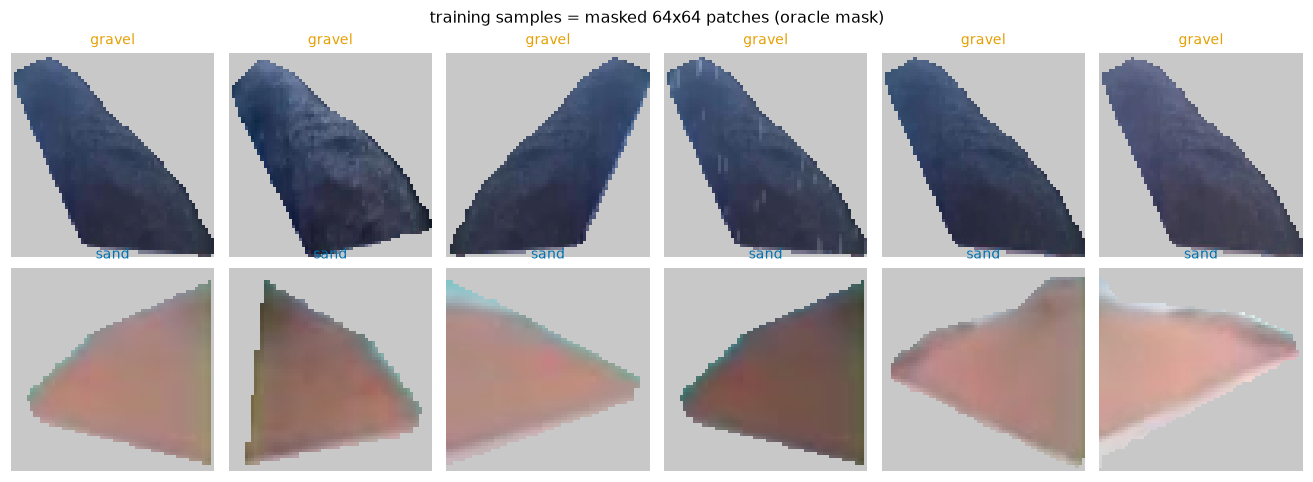

In [3]:
# ============================================================
# 1.1 CROPS -> fixed 64x64 tensors + GALLERY
# ============================================================
PATCH = 64

def read_polys(lbl_path):
    out = []
    for line in lbl_path.read_text().splitlines():
        if not line.strip():
            continue
        p = line.split()
        out.append((int(p[0]), np.array(list(map(float, p[1:]))).reshape(-1, 2)))
    return out

def inst_crop(img_rgb, poly_norm, pad=3):
    h, w = img_rgb.shape[:2]
    px = poly_norm * [w, h]
    x0, y0 = np.clip(px.min(0).astype(int) - pad, 0, [w - 1, h - 1])
    x1, y1 = np.clip(px.max(0).astype(int) + pad, 0, [w, h])
    crop = img_rgb[y0:y1, x0:x1].copy()
    m = np.zeros((y1 - y0, x1 - x0), np.uint8)
    cv2.fillPoly(m, [(px - [x0, y0]).astype(np.int32)], 1)
    return crop, m.astype(bool)


t0 = time.time()
RGBl, HSVl, LABl, GRAYl, MASKl, keep = [], [], [], [], [], []
for r_i, (_, r) in enumerate(inst.iterrows()):
    ds_root = GOLD_AUG if r.ds == "gold_aug" else GOLD
    img = np.asarray(Image.open(ds_root / r.split / "images" / r.img).convert("RGB"))
    polys = read_polys(ds_root / r.split / "labels" / (r.stem + ".txt"))
    crop, m = inst_crop(img, polys[r.inst_i][1])
    if m.sum() < 25:
        continue
    c64 = cv2.resize(crop, (PATCH, PATCH), interpolation=cv2.INTER_AREA)
    m64 = cv2.resize(m.astype(np.uint8), (PATCH, PATCH),
                     interpolation=cv2.INTER_NEAREST).astype(bool)
    RGBl.append(c64); MASKl.append(m64); keep.append(r_i)
    HSVl.append(cv2.cvtColor(c64, cv2.COLOR_RGB2HSV))
    LABl.append(cv2.cvtColor(c64, cv2.COLOR_RGB2LAB))
    GRAYl.append(cv2.cvtColor(c64, cv2.COLOR_RGB2GRAY))

inst_f = inst.loc[keep].reset_index(drop=True)
RGB  = torch.from_numpy(np.stack(RGBl)).to(DEV_T)          # N,64,64,3
HSV  = torch.from_numpy(np.stack(HSVl)).to(DEV_T)
LAB  = torch.from_numpy(np.stack(LABl)).to(DEV_T)
GRAY = torch.from_numpy(np.stack(GRAYl)).to(DEV_T)         # N,64,64
MASK = torch.from_numpy(np.stack(MASKl)).to(DEV_T)         # N,64,64 bool
y = inst_f["cls"].to_numpy(); groups = inst_f["group"].to_numpy()
del RGBl, HSVl, LABl, GRAYl, MASKl
extract_s = time.time() - t0
print(f"{len(keep)} patches on {DEV_T} in {extract_s:.0f}s |",
      f"VRAM {torch.cuda.memory_allocated()/1e9:.2f} GB" if DEV_T.type=='cuda' else '')

fig, axes = plt.subplots(2, 6, figsize=(12, 4.4))
for row, cls in enumerate((0, 1)):
    idx = np.flatnonzero((y == cls) & (inst_f.split == 'train'))[:6]
    for ax, j in zip(axes[row], idx):
        ax.imshow(np.where(MASK[j,...,None].cpu(), RGB[j].cpu().numpy(), 200))
        ax.set_title(CLASS_NAMES[cls], color=CLASS_COLORS[cls], fontsize=9)
        ax.axis("off")
plt.suptitle("training samples = masked 64x64 patches (oracle mask)")
plt.tight_layout(); plt.show(); plt.close("all")

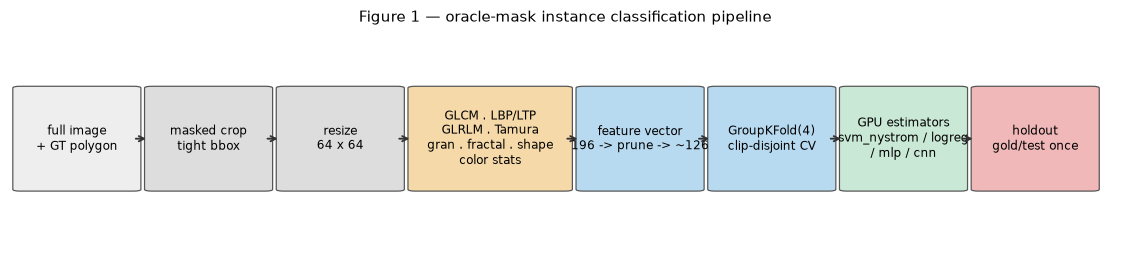

In [4]:
# ============================================================
# 1.2 FIGURE 1 — feature-extraction pipeline schematic
# ============================================================
fig, ax = plt.subplots(figsize=(13, 2.6)); ax.axis("off")
boxes = [
    ("full image\n+ GT polygon", "#EEEEEE"),
    ("masked crop\ntight bbox", "#DDDDDD"),
    ("resize\n64 x 64", "#DDDDDD"),
    ("GLCM . LBP/LTP\nGLRLM . Tamura\ngran . fractal . shape\ncolor stats", "#F5D9A8"),
    ("feature vector\n196 -> prune -> ~126", "#B8DAF0"),
    ("GroupKFold(4)\nclip-disjoint CV", "#B8DAF0"),
    ("GPU estimators\nsvm_nystrom / logreg\n/ mlp / cnn", "#C9E8D5"),
    ("holdout\ngold/test once", "#F0B8B8"),
]
x = 0.0
for i, (txt, c) in enumerate(boxes):
    w = 0.14 if i != 3 else 0.18
    ax.add_patch(mpl.patches.FancyBboxPatch((x, 0.28), w - 0.015, 0.46,
                 boxstyle="round,pad=0.008", fc=c, ec="#555555", lw=0.8))
    ax.text(x + (w - 0.015) / 2, 0.51, txt, ha="center", va="center", fontsize=7.6)
    if i < len(boxes) - 1:
        ax.annotate("", xy=(x + w + 0.002, 0.51), xytext=(x + w - 0.016, 0.51),
                    arrowprops=dict(arrowstyle="->", lw=1.2, color="#333333"))
    x += w + 0.005
ax.set_xlim(-0.01, x + 0.01); ax.set_ylim(0, 1)
ax.set_title("Figure 1 — oracle-mask instance classification pipeline", fontsize=10)
plt.show(); plt.close("all")

## 2. Feature engineering — *what does each family actually see?*

VIZ FIRST: one gravel + one sand patch pushed through every family's raw
representation (GLCM matrix, LBP map, LTP maps, granulometry spectrum,
gradient-direction histogram) before any numbers are extracted.

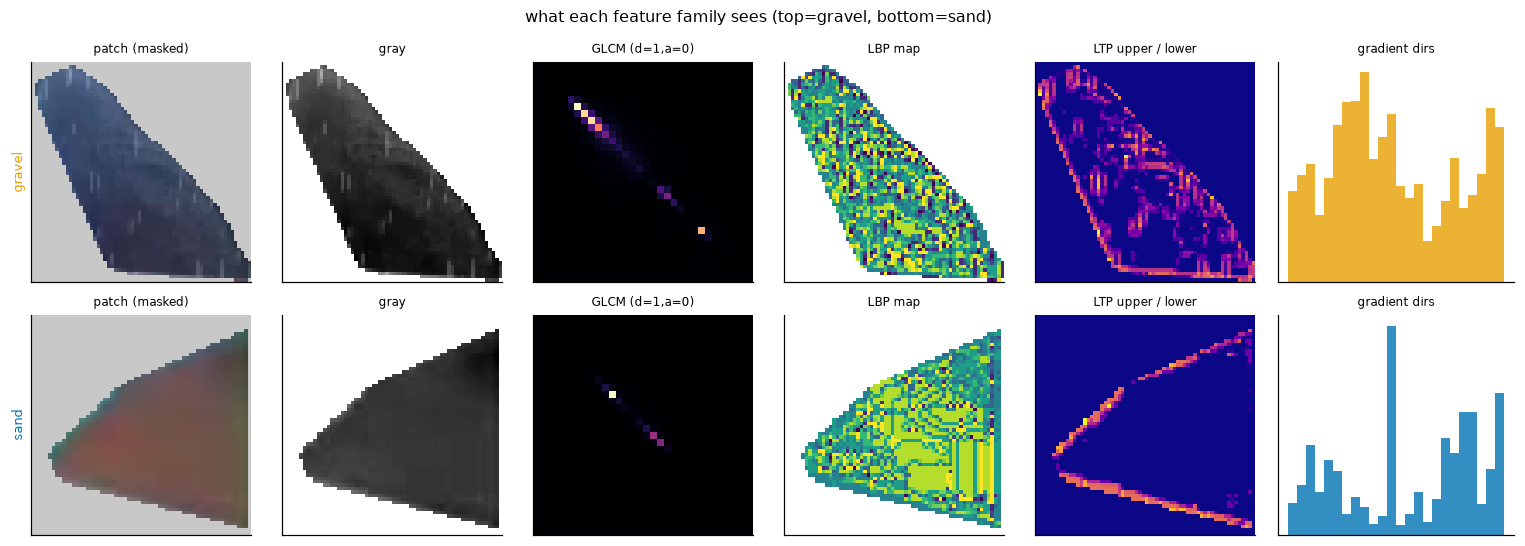

In [5]:
# ============================================================
# 2.1 VIZ — feature sources per family, gravel vs sand
# ============================================================
def lbp_map_np(g, P=8, R=1):
    from skimage.feature import local_binary_pattern
    return local_binary_pattern(g, P, R, "uniform")

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
titles = ["patch (masked)", "gray", "GLCM (d=1,a=0)", "LBP map",
          "LTP upper / lower", "gradient dirs"]
from skimage.feature import graycomatrix
for row, cls in enumerate((0, 1)):
    j = np.flatnonzero((y == cls) & (inst_f.split == 'train'))[3]
    g   = GRAY[j].cpu().numpy(); m = MASK[j].cpu().numpy()
    rgb = RGB[j].cpu().numpy()
    axes[row,0].imshow(np.where(m[...,None], rgb, 200))
    axes[row,1].imshow(np.where(m, g, 200), cmap="gray")
    gq = np.clip((g.astype(np.float32)/256*32).astype(np.uint8), 0, 31)
    P_ = graycomatrix(gq, [1], [0], levels=32, symmetric=True, normed=True)
    axes[row,2].imshow(np.log1p(P_[:,:,0,0]), cmap="magma")
    axes[row,3].imshow(np.where(m, lbp_map_np(g), np.nan), cmap="viridis")
    nb = [np.roll(np.roll(g, -dy, 0), -dx, 1) for dy,dx in
          [(-1,-1),(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1)]]
    d  = np.stack(nb) - g.astype(np.int16)
    up = (d > 5).sum(0); lo = (d < -5).sum(0)
    ltp = np.where(m, up*20, 0) + np.where(m, lo*2, 0)
    axes[row,4].imshow(ltp, cmap="plasma")
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    ang = np.degrees(np.arctan2(gy, gx))[m]
    axes[row,5].hist(ang, bins=24, color=CLASS_COLORS[cls], alpha=0.8)
    for k, t in enumerate(titles):
        axes[row,k].set_title(t, fontsize=8); axes[row,k].set_xticks([]); axes[row,k].set_yticks([])
    axes[row,0].set_ylabel(CLASS_NAMES[cls], color=CLASS_COLORS[cls])
plt.suptitle("what each feature family sees (top=gravel, bottom=sand)")
plt.tight_layout(); plt.show(); plt.close("all")

### 2.2 GPU extractors — GLCM, LBP, LTP, color stats (batched on RX 7800 XT)

In [6]:
# ============================================================
# 2.2a GLCM on GPU — 12 offsets, 32 levels, 6 props = 72 dims
# ============================================================
L_GLCM = 32
OFFS = [(d, 0) for d in (1, 2, 4)] + [(d, d) for d in (1, 2, 4)] \
     + [(0, d) for d in (1, 2, 4)] + [(-d, d) for d in (1, 2, 4)]
II, JJ = torch.meshgrid(torch.arange(L_GLCM, device=DEV_T),
                        torch.arange(L_GLCM, device=DEV_T), indexing="ij")
DIJ = (II - JJ).float()

def glcm_batch(Q, M):
    """Q (N,H,W) int64 quantized; M bool. -> (N, 12, 6) props."""
    N, H, W = Q.shape; L = L_GLCM
    P = torch.zeros(N, len(OFFS), L, L, device=Q.device)
    for k, (dy, dx) in enumerate(OFFS):
        ys  = slice(max(0, -dy), min(H, H - dy))
        xs  = slice(max(0, -dx), min(W, W - dx))
        ys2 = slice(ys.start + dy, ys.stop + dy)
        xs2 = slice(xs.start + dx, xs.stop + dx)
        g1, g2 = Q[:, ys, xs], Q[:, ys2, xs2]
        v = (M[:, ys, xs] & M[:, ys2, xs2]).flatten(1)
        idx = (g1 * L + g2).flatten(1)
        P[:, k] = torch.zeros(N, L * L, device=Q.device)\
            .scatter_add_(1, idx, v.float()).view(N, L, L)
    P = P / P.sum((2, 3), keepdim=True).clamp_min(1e-9)   # N,12,L,L
    con = (P * DIJ**2).sum((2, 3))
    dis = (P * DIJ.abs()).sum((2, 3))
    hom = (P / (1 + DIJ**2)).sum((2, 3))
    ene = (P**2).sum((2, 3))
    ent = -(P * torch.log(P.clamp_min(1e-9))).sum((2, 3))
    mu_i = (P.sum(3) * torch.arange(L, device=Q.device)[None, None]).sum(2)
    mu_j = (P.sum(2) * torch.arange(L, device=Q.device)[None, None]).sum(2)
    sd_i = ((P.sum(3) * (torch.arange(L, device=Q.device)[None, None]
            - mu_i[..., None])**2).sum(2)).clamp_min(1e-9).sqrt()
    sd_j = ((P.sum(2) * (torch.arange(L, device=Q.device)[None, None]
            - mu_j[..., None])**2).sum(2)).clamp_min(1e-9).sqrt()
    cor = (P * ((II - mu_i[:, :, None, None]) * (JJ - mu_j[:, :, None, None]))
           ).sum((2, 3)) / (sd_i * sd_j)
    return torch.stack([con, dis, hom, ene, cor, ent], -1)   # N,12,6


Q32 = torch.clamp((GRAY.float() / 256 * L_GLCM).long(), 0, L_GLCM - 1)
glcm_feats = glcm_batch(Q32, MASK)                       # N,12,6
glcm_names = [f"glcm_{p}_d{abs(dy) or abs(dx)}_a{a}"
              for p in ["con", "dis", "hom", "ene", "cor", "ent"]
              for (dy, dx), a in zip(OFFS, [0]*3 + [45]*3 + [90]*3 + [135]*3)]
print("GLCM:", glcm_feats.shape, "->", len(glcm_names), "names")

GLCM: torch.Size([12224, 12, 6]) -> 72 names


In [7]:
# ============================================================
# 2.2b LBP + LTP on GPU — uniform patterns, masked histograms
# ============================================================
NEI = [(-1, -1), (-1, 0), (-1, 1), (0, 1), (1, 1), (1, 0), (1, -1), (0, -1)]

def _uniform_lut():
    lut = np.zeros(256, np.int64); k = 0
    for p in range(256):
        b = format(p, "08b")
        if sum(b[i] != b[(i + 1) % 8] for i in range(8)) <= 2:
            lut[p] = k; k += 1
        else:
            lut[p] = 58
    lut[58:] = 58
    out = np.full(256, 9); out[:59] = np.minimum(np.arange(256)[:59], 9)
    for p in range(256):
        b = format(p, "08b")
        out[p] = p if sum(b[i] != b[(i + 1) % 8] for i in range(8)) <= 2 else 9
    return torch.from_numpy(out)

LUT = _uniform_lut().to(DEV_T)      # maps pattern -> 0..9 (9 = non-uniform bin)
BIT = torch.tensor([1 << k for k in range(8)], device=DEV_T)[:, None, None]

def neighbor_stack(G):
    Gp = torch.nn.functional.pad(G[:, None].float(), (1, 1, 1, 1),
                                 mode="replicate")[:, 0]
    return torch.stack([Gp[:, 1+dy:65+dy, 1+dx:65+dx] for dy, dx in NEI])

def lbp_ltp_batch(G, M, t=5.0):
    nb = neighbor_stack(G)                       # 8,N,64,64
    ge = (nb >= G[None]).long()                  # for LBP
    pat = (ge * BIT[:, None]).sum(0)             # N,64,64
    up  = ((nb - G[None]) > t).long()
    lo  = ((nb - G[None]) < -t).long()
    pat_u = (up * BIT[:, None]).sum(0); pat_l = (lo * BIT[:, None]).sum(0)
    N = G.shape[0]; H = torch.zeros(N, 30, device=G.device)
    for p_in, off in ((pat, 0), (pat_u, 10), (pat_l, 20)):
        b = LUT[p_in].flatten(1)
        H[:, off:off+10] = torch.zeros(N, 10, device=G.device)\
            .scatter_add_(1, b, M.flatten(1).float())
    return H / M.flatten(1).sum(1, keepdim=True).clamp_min(1)

lbp_feats = torch.cat([lbp_ltp_batch(GRAY[s:s+2048].float(), MASK[s:s+2048])
                       for s in range(0, GRAY.shape[0], 2048)])
torch.cuda.empty_cache() if DEV_T.type == 'cuda' else None
lbp_names = ([f"lbp_{i}" for i in range(10)]
             + [f"ltp_u_{i}" for i in range(10)]
             + [f"ltp_l_{i}" for i in range(10)])
print("LBP+LTP:", lbp_feats.shape)

LBP+LTP: torch.Size([12224, 30])


In [8]:
# ============================================================
# 2.2c COLOR stats on GPU — mean/std/skew of RGB+HSV+Lab = 27
# ============================================================
def color_stats_batch(T, M):
    """T (N,H,W,3) uint8 -> masked mean/std/skew per channel = 9."""
    x = T.permute(0, 3, 1, 2).float()            # N,3,H,W
    w = M[:, None].float()
    n = w.sum((2, 3), keepdim=True).clamp_min(1)
    mu = (x * w).sum((2, 3), keepdim=True) / n
    sd = (((x - mu) * w)**2).sum((2, 3), keepdim=True).div(n).sqrt()
    sk = (((x - mu) * w)**3).sum((2, 3), keepdim=True) / n / sd.clamp_min(1e-6)**3
    return torch.cat([mu, sd, sk], 1).squeeze(-1).squeeze(-1)   # N,9

def col_all(T):
    return torch.cat([color_stats_batch(T[s:s+2048], MASK[s:s+2048])
                      for s in range(0, T.shape[0], 2048)])

col_feats = torch.cat([col_all(RGB), col_all(HSV), col_all(LAB)], 1)  # N,27
torch.cuda.empty_cache() if DEV_T.type == 'cuda' else None
col_names = [f"{sp}_{s}_{c}" for sp in ("rgb", "hsv", "lab")
             for s in ("mean", "std", "skew") for c in range(3)]
print("COLOR:", col_feats.shape)

COLOR: torch.Size([12224, 27])


### 2.3 CPU extractors — GLRLM, Tamura, granulometry, fractal, shape
(scalar/small-matrix families; cheap on CPU, still GPU where it matters)

In [9]:
# ============================================================
# 2.3a GLRLM — run-length props x 4 dirs = 28  (Galloway '75)
# ============================================================
def glrlm_one(g, m, levels=8):
    gq = np.clip((g.astype(np.float32)/256*levels).astype(np.uint8), 0, levels-1)
    gq[~m] = levels  # sentinel
    R = np.zeros((levels, PATCH), np.float64)
    lines = []
    for rot in range(4):
        gr = np.rot90(gq, rot)
        for row in gr:
            run_val, run_len = -1, 0
            for v in row:
                if v == run_val:
                    run_len += 1
                else:
                    if run_val != levels and run_len:
                        R[run_val, min(run_len, PATCH) - 1] += 1
                    run_val, run_len = v, 1
            if run_val != levels and run_len:
                R[run_val, min(run_len, PATCH) - 1] += 1
        lines.append(R.copy()); R[:] = 0
    feats = []
    i_g = np.arange(levels)[:, None]; j_l = np.arange(1, PATCH + 1)[None]
    for R in lines:
        s = R.sum()
        if s == 0:
            feats += [0] * 7; continue
        p = R / s
        feats += [
            (p / j_l**2).sum(),              # SRE
            (p * j_l**2).sum(),              # LRE
            (p.sum(1) / (i_g[:, 0] + 1)**2).sum(),   # GLN
            (p.sum(0) / (np.arange(1, PATCH+1))**2).sum(),  # RLN
            s / m.sum(),                     # RP
            (p / (i_g + 1)**2).sum(),        # LGRE
            (p * (i_g + 1)**2).sum(),        # HGRE
        ]
    return feats

glrlm_names = [f"glrlm_{p}_d{a}" for p in
               ("sre", "lre", "gln", "rln", "rp", "lgre", "hgre")
               for a in (0, 45, 90, 135)]

In [10]:
# ============================================================
# 2.3b TAMURA (coarseness, contrast, dir-hist) + GRANULOMETRY + FRACTAL + SHAPE
# ============================================================
def tamura_one(g, m):
    gf = g.astype(np.float32)
    best = np.zeros(g.shape); n = m.sum()
    for k in range(1, 6):
        w = 2**k
        E = cv2.boxFilter(gf, -1, (w, w), normalize=True)
        dh = np.abs(np.roll(E, w, 1) - E); dv = np.abs(np.roll(E, w, 0) - E)
        best = np.maximum(best, np.maximum(dh, dv))
    coarse = best[m].mean() if n else 0
    sd = gf[m].std(); kurt = ((gf[m]-gf[m].mean())**4).mean()/max(sd**4, 1e-9)
    contrast = sd / max(kurt, 1e-9)**0.25
    gx = cv2.Sobel(gf, cv2.CV_32F, 1, 0, 3); gy = cv2.Sobel(gf, cv2.CV_32F, 0, 1, 3)
    mag = np.hypot(gx, gy)[m]; ang = np.degrees(np.arctan2(gy[m], gx[m])) + 180
    hist, _ = np.histogram(ang[mag > mag.mean()], bins=16, range=(0, 360),
                           density=True)
    return [coarse, contrast] + hist.tolist()

def granulometry_one(g, m):
    gf = np.where(m, g, np.median(g[m])).astype(np.uint8)
    prev = gf.astype(np.float64)[m].sum(); diffs = []
    for k in range(1, 8):
        ker = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2*k+1, 2*k+1))
        opened = float(cv2.morphologyEx(gf, cv2.MORPH_OPEN, ker)[m].sum())
        diffs.append(max(prev - opened, 0) / max(prev, 1))
        prev = opened
    return diffs

def fractal_one(g, m):
    e = (cv2.Canny(np.where(m, g, 0), 40, 120) > 0)
    sizes, counts = [], []
    for s in (2, 4, 8, 16, 32):
        h, w = e.shape
        boxes = e[:h//s*s, :w//s*s].reshape(h//s, s, w//s, s).any((1, 3)).sum()
        if boxes > 0:
            sizes.append(np.log(1/s)); counts.append(np.log(boxes))
    return [np.polyfit(sizes, counts, 1)[0] if len(sizes) > 1 else 0]

def shape_one(m):
    mu8 = m.astype(np.uint8)
    cnts, _ = cv2.findContours(mu8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    area = m.sum(); peri = sum(cv2.arcLength(c, True) for c in cnts) or 1
    hull = cv2.convexHull(cnts[0]) if cnts else np.zeros((1, 1, 2), int)
    hull_a = cv2.contourArea(hull) or 1
    mom = cv2.moments(mu8); hu = cv2.HuMoments(mom).ravel()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-30)
    ys, xs = np.nonzero(m)
    ar = ((xs.max()-xs.min()+1) / max(ys.max()-ys.min()+1, 1)) if len(xs) else 1
    return [area/4096, peri/np.sqrt(area+1), 4*np.pi*area/max(peri**2, 1),
            area/max(hull_a, 1), ar] + hu.tolist()[:7]

misc_names = ([f"tam_{n}" for n in ("coarse", "contrast")]
              + [f"tam_dir_{i}" for i in range(16)]
              + [f"gran_{k}" for k in range(1, 8)]
              + ["fractal_dim"]
              + [f"shape_{n}" for n in
                 ("area", "peri", "circ", "solid", "ar",
                  "hu1", "hu2", "hu3", "hu4", "hu5", "hu6", "hu7")])

### 2.4 Build matrix — GPU families + CPU families, timed

VIZ: GPU-vs-CPU timing on a subset first (evidence the offload is worth it),
then the full pass.

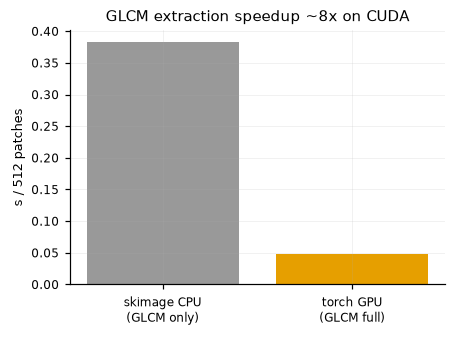

cpu 0.4s vs gpu 0.05s -> 8x


In [11]:
# ============================================================
# 2.4a TIMING — GPU batch vs CPU equivalent on 512 instances
# ============================================================
from skimage.feature import graycomatrix as sk_glcm, graycoprops as sk_prop
sub = slice(0, 512)
t_gpu = time.time()
_ = glcm_batch(Q32[sub], MASK[sub]); torch.cuda.synchronize() if DEV_T.type=='cuda' else None
t_gpu = time.time() - t_gpu

t_cpu = time.time()
for j in range(512):
    g = np.clip((GRAY[j].cpu().numpy().astype(np.float32)/256*32).astype(np.uint8),0,31)
    P_ = sk_glcm(g, [1,2,4], [0, np.pi/4, np.pi/2, 3*np.pi/4], levels=32,
                 symmetric=True, normed=True)
    [sk_prop(P_, p) for p in ("contrast","dissimilarity","homogeneity","energy")]
t_cpu = time.time() - t_cpu

plt.figure(figsize=(4.4, 3))
plt.bar(["skimage CPU\n(GLCM only)", "torch GPU\n(GLCM full)"], [t_cpu, t_gpu],
        color=["#999999", "#E69F00"])
plt.ylabel("s / 512 patches")
plt.title(f"GLCM extraction speedup ~{t_cpu/max(t_gpu,0.01):.0f}x on {DEV_T.type.upper()}")
plt.show(); plt.close("all")
print(f"cpu {t_cpu:.1f}s vs gpu {t_gpu:.2f}s -> {t_cpu/max(t_gpu,0.01):.0f}x")

In [12]:
# ============================================================
# 2.4b FULL EXTRACTION — all families -> X (N x 196)
# ============================================================
t0 = time.time()
G_cpu = GRAY.cpu().numpy(); M_cpu = MASK.cpu().numpy()
misc = np.stack([np.array(glrlm_one(G_cpu[j], M_cpu[j])
                          + tamura_one(G_cpu[j], M_cpu[j])
                          + granulometry_one(G_cpu[j], M_cpu[j])
                          + fractal_one(G_cpu[j], M_cpu[j])
                          + shape_one(M_cpu[j]))
                 for j in range(len(G_cpu))])
X = np.concatenate([col_feats.cpu().numpy(), glcm_feats.reshape(len(G_cpu), -1).cpu().numpy(),
                    lbp_feats.cpu().numpy(), misc], 1)
FEAT_NAMES = col_names + glcm_names + lbp_names + glrlm_names + misc_names
assert X.shape[1] == len(FEAT_NAMES), (X.shape, len(FEAT_NAMES))
np.save(RES_DIR / "ml_features.npy", X)
inst_f.to_csv(RES_DIR / "ml_instances.csv", index=False)
print(f"X = {X.shape} ({len(FEAT_NAMES)} named) in {time.time()-t0:.0f}s")

FAM = {"color": slice(0, 27), "glcm": slice(27, 99), "lbp_ltp": slice(99, 129),
       "glrlm": slice(129, 157), "tamura": slice(157, 175),
       "gran": slice(175, 182), "fractal": slice(182, 183), "shape": slice(183, 196)}
B106 = ([i for i, n in enumerate(FEAT_NAMES) if n.startswith("hsv_")]
        + list(range(27, 99)) + list(range(99, 109)))
print({k: (v.stop - v.start) for k, v in FAM.items()}, "| baseline106 =", len(B106))

X = (12224, 195) (195 named) in 35s
{'color': 27, 'glcm': 72, 'lbp_ltp': 30, 'glrlm': 28, 'tamura': 18, 'gran': 7, 'fractal': 1, 'shape': 13} | baseline106 = 91


### 2.5 Paper figures per feature family

Per figure spec: every family gets its raw transform evidence + class-wise
comparison BEFORE modeling — GLCM heatmaps/props/directions, LBP code map +
histogram, LTP ternary maps + τ sensitivity, color distributions.

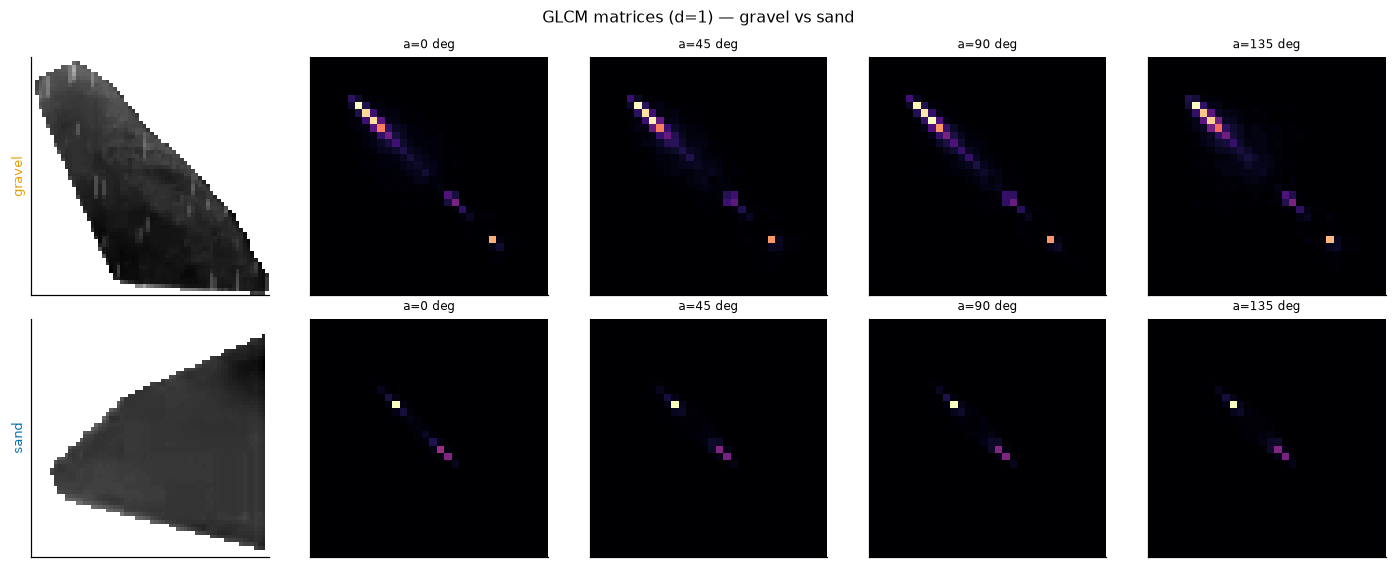

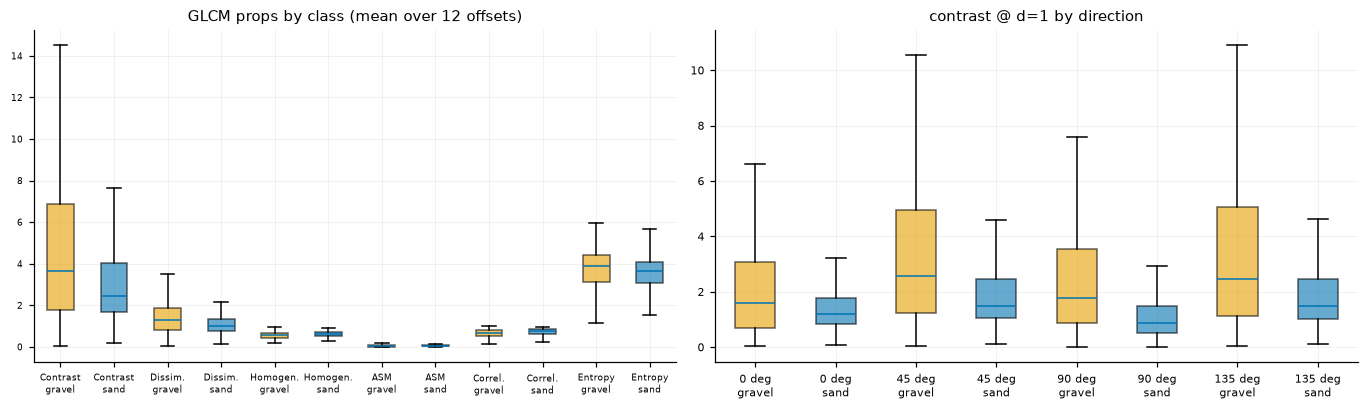

In [13]:
# ============================================================
# 2.5a GLCM figures — heatmaps, grouped prop boxplots, directions
# (ASM == energy on normalized GLCM — shown as 'ASM' per spec)
# ============================================================
from skimage.feature import graycomatrix as _gc
devmask = inst_f.split.isin(["train", "valid"]).to_numpy()
gfeat = glcm_feats.cpu().numpy()                    # N,12,6
PROP = ["con", "dis", "hom", "ASM", "cor", "ent"]   # order matches glcm_names
PLAB = {"con": "Contrast", "dis": "Dissim.", "hom": "Homogen.",
        "ASM": "ASM", "cor": "Correl.", "ent": "Entropy"}

# (a) GLCM matrices d=1 at 4 angles — gravel vs sand
fig, axes = plt.subplots(2, 5, figsize=(13, 5.2))
for row, cls in enumerate((0, 1)):
    j = np.flatnonzero((y == cls) & devmask)[3]
    g = GRAY[j].cpu().numpy(); m = MASK[j].cpu().numpy()
    gq = np.clip((g.astype(np.float32) / 256 * 32).astype(np.uint8), 0, 31)
    axes[row, 0].imshow(np.where(m, g, 200), cmap="gray")
    axes[row, 0].set_ylabel(CLASS_NAMES[cls], color=CLASS_COLORS[cls])
    for k, a in enumerate([0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]):
        P_ = _gc(gq, [1], [a], levels=32, symmetric=True, normed=True)[:, :, 0, 0]
        axes[row, k + 1].imshow(np.log1p(P_), cmap="magma")
        axes[row, k + 1].set_title(f"a={int(np.degrees(a))} deg", fontsize=8)
for ax_ in axes.ravel():
    ax_.set_xticks([]); ax_.set_yticks([])
plt.suptitle("GLCM matrices (d=1) — gravel vs sand")
plt.tight_layout(); plt.show(); plt.close("all")

# (b) grouped boxplots: 6 props (mean over 12 offsets) + (c) direction comparison
fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
gm = gfeat[devmask].mean(1)                          # dev,6
dat, lab, col = [], [], []
for pi, p in enumerate(PROP):
    for cls in (0, 1):
        dat.append(gm[y[devmask] == cls, pi])
        lab.append(f"{PLAB[p]}\n{CLASS_NAMES[cls]}"); col.append(CLASS_COLORS[cls])
bp = ax[0].boxplot(dat, tick_labels=lab, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], col):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax[0].set_title("GLCM props by class (mean over 12 offsets)"); ax[0].tick_params(labelsize=6)

d1_idx = [0, 3, 6, 9]                                # d=1 at 4 angles
dat2, lab2, col2 = [], [], []
for k, a in enumerate([0, 45, 90, 135]):
    for cls in (0, 1):
        dat2.append(gfeat[devmask][y[devmask] == cls, d1_idx[k], 0])
        lab2.append(f"{a} deg\n{CLASS_NAMES[cls]}"); col2.append(CLASS_COLORS[cls])
bp = ax[1].boxplot(dat2, tick_labels=lab2, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], col2):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax[1].set_title("contrast @ d=1 by direction"); ax[1].tick_params(labelsize=7)
plt.tight_layout(); plt.show(); plt.close("all")

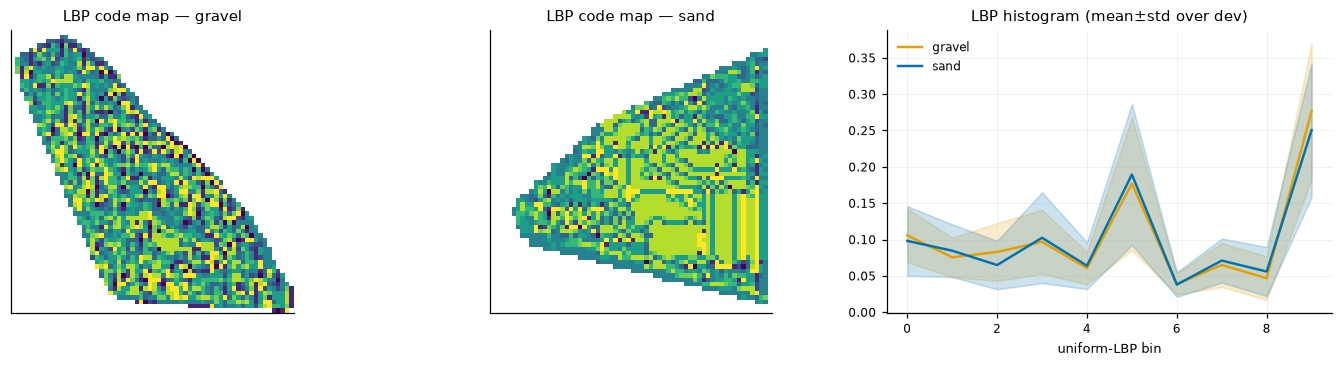

In [14]:
# ============================================================
# 2.5b LBP figures — code map + class-wise normalized histogram
# ============================================================
from skimage.feature import local_binary_pattern
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for k, cls in enumerate((0, 1)):
    j = np.flatnonzero((y == cls) & devmask)[3]
    g = GRAY[j].cpu().numpy(); m = MASK[j].cpu().numpy()
    axes[k].imshow(np.where(m, local_binary_pattern(g, 8, 1, "uniform"), np.nan),
                   cmap="viridis")
    axes[k].set_title(f"LBP code map — {CLASS_NAMES[cls]}")
    axes[k].set_xticks([]); axes[k].set_yticks([])
lh = lbp_feats[:, 0:10].cpu().numpy()
for cls in (0, 1):
    mu = lh[devmask & (y == cls)].mean(0); sd = lh[devmask & (y == cls)].std(0)
    axes[2].plot(mu, color=CLASS_COLORS[cls], label=CLASS_NAMES[cls])
    axes[2].fill_between(range(10), mu - sd, mu + sd, alpha=0.2,
                         color=CLASS_COLORS[cls])
axes[2].set_title("LBP histogram (mean±std over dev)")
axes[2].set_xlabel("uniform-LBP bin"); axes[2].legend()
plt.tight_layout(); plt.show(); plt.close("all")

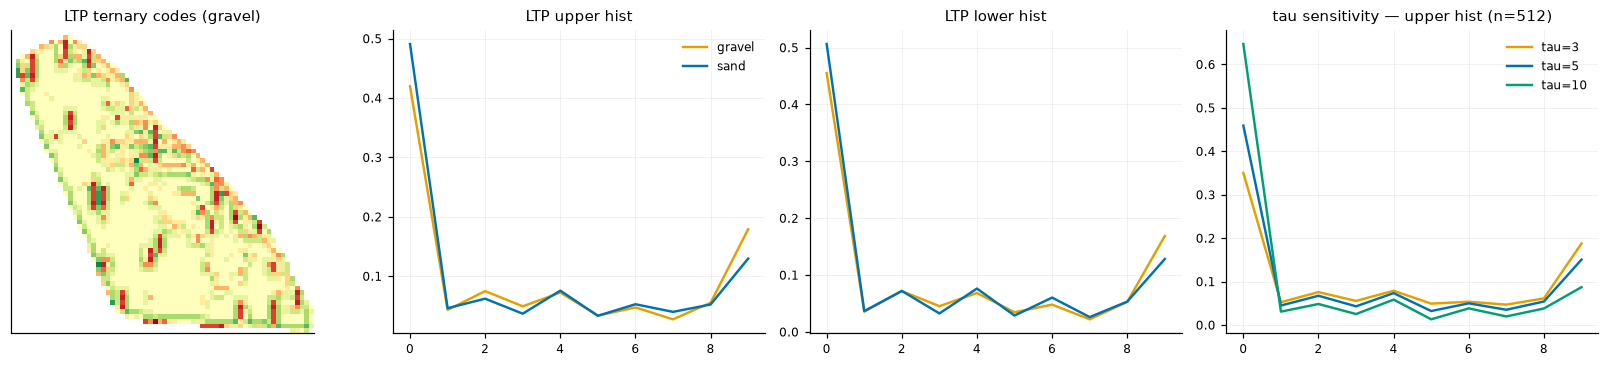

In [15]:
# ============================================================
# 2.5c LTP figures — ternary map, upper/lower histograms, tau sensitivity
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
j = np.flatnonzero((y == 0) & devmask)[3]
g = GRAY[j].cpu().numpy().astype(np.int16); m = MASK[j].cpu().numpy()
nb = np.stack([np.roll(np.roll(g, -dy, 0), -dx, 1)
               for dy, dx in [(-1,-1),(-1,0),(-1,1),(0,1),(1,1),(1,0),(1,-1),(0,-1)]])
d = nb - g[None]
tern = np.where(d > 5, 1, np.where(d < -5, -1, 0)).sum(0)
axes[0].imshow(np.where(m, tern, np.nan), cmap="RdYlGn", vmin=-8, vmax=8)
axes[0].set_title("LTP ternary codes (gravel)"); axes[0].set_xticks([]); axes[0].set_yticks([])
lu = lbp_feats[:, 10:20].cpu().numpy(); ll = lbp_feats[:, 20:30].cpu().numpy()
for cls in (0, 1):
    axes[1].plot(lu[devmask & (y == cls)].mean(0), color=CLASS_COLORS[cls],
                 label=CLASS_NAMES[cls])
    axes[2].plot(ll[devmask & (y == cls)].mean(0), color=CLASS_COLORS[cls],
                 label=CLASS_NAMES[cls])
axes[1].set_title("LTP upper hist"); axes[2].set_title("LTP lower hist")
axes[1].legend()
sub_idx = rng.choice(np.flatnonzero(devmask), 512, replace=False)
for t in (3.0, 5.0, 10.0):
    H = lbp_ltp_batch(GRAY[sub_idx].float(), MASK[sub_idx], t=t)[:, 10:20]
    axes[3].plot(H.cpu().numpy().mean(0), label=f"tau={t:g}")
axes[3].set_title("tau sensitivity — upper hist (n=512)"); axes[3].legend(fontsize=8)
plt.tight_layout(); plt.show(); plt.close("all")

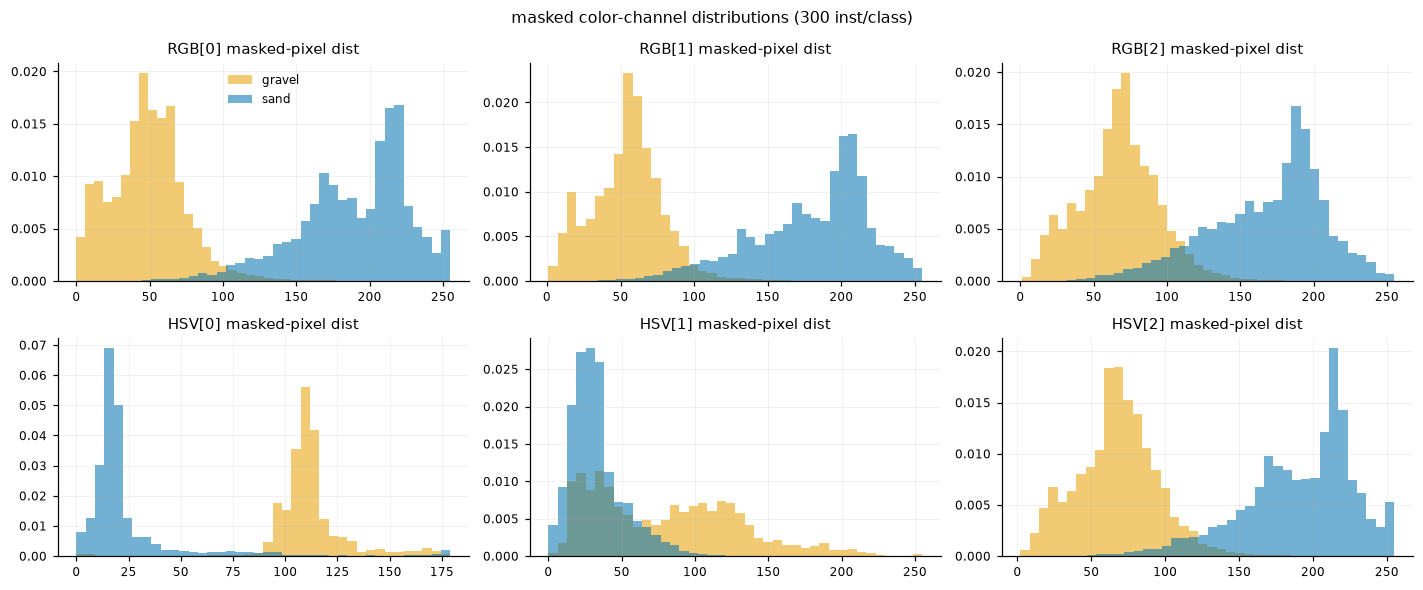

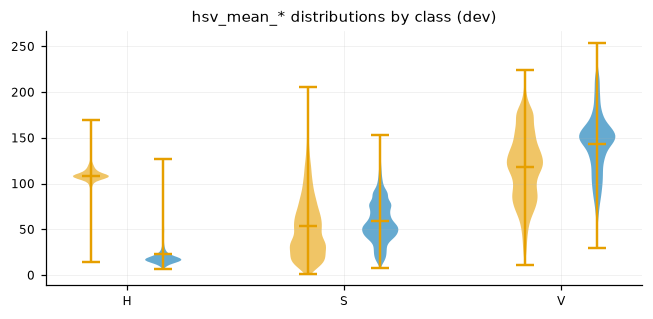

In [16]:
# ============================================================
# 2.5d COLOR figures — masked channel histograms + HSV violin
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(13, 5.4))
for c, (sp, T) in enumerate([("RGB", RGB), ("HSV", HSV)]):
    for ch in range(3):
        ax_ = axes[c, ch]
        for cls in (0, 1):
            jj = np.flatnonzero(devmask & (y == cls))[:300]
            vals = torch.cat([T[j, ..., ch][MASK[j]] for j in jj]).cpu().numpy()
            ax_.hist(vals, bins=40, density=True, alpha=0.55,
                     color=CLASS_COLORS[cls], label=CLASS_NAMES[cls])
        ax_.set_title(f"{sp}[{ch}] masked-pixel dist")
axes[0, 0].legend()
plt.suptitle("masked color-channel distributions (300 inst/class)")
plt.tight_layout(); plt.show(); plt.close("all")

# violin — hsv mean features by class (feature-space, dev)
fig, ax_ = plt.subplots(figsize=(7, 3))
pos, dat, col = [], [], []
for ch, nm in enumerate("HSV"):
    i = FEAT_NAMES.index(f"hsv_mean_{ch}")
    for cls in (0, 1):
        dat.append(X[devmask][y[devmask] == cls, i])
        pos.append(ch * 3 + cls); col.append(CLASS_COLORS[cls])
vp = ax_.violinplot(dat, positions=pos, showmeans=True)
for b, c in zip(vp["bodies"], col):
    b.set_facecolor(c); b.set_alpha(0.6)
ax_.set_xticks([p + 0.5 for p in range(0, 9, 3)], ["H", "S", "V"])
ax_.set_title("hsv_mean_* distributions by class (dev)")
plt.show(); plt.close("all")

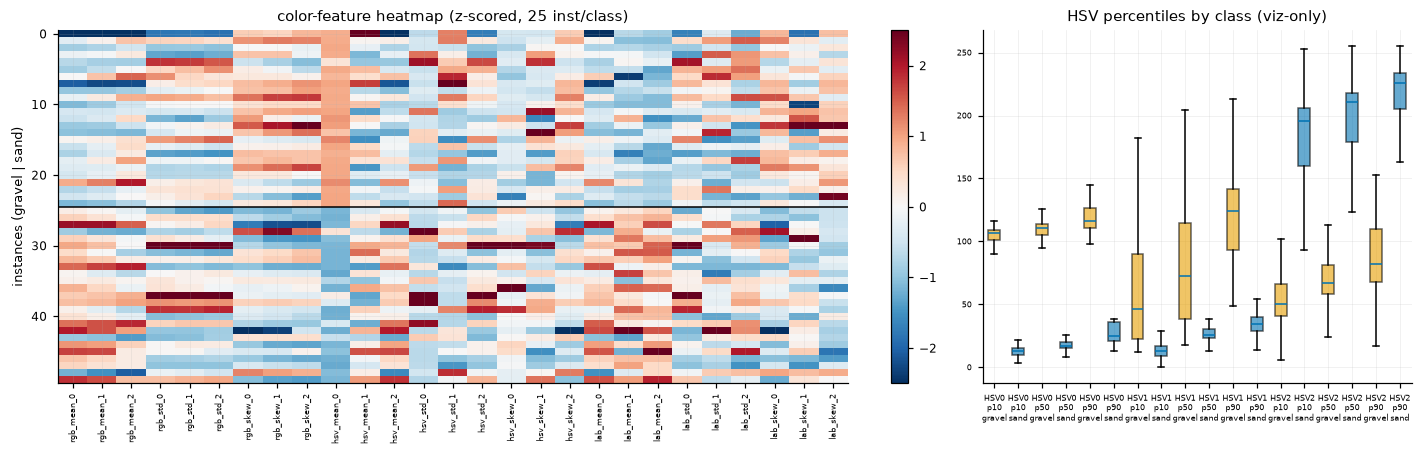

In [17]:
# ============================================================
# 2.5e COLOR (cont.) — feature heatmap + percentile comparison
# ============================================================
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [2, 1]})
col_idx = [FEAT_NAMES.index(n) for n in FEAT_NAMES if n.startswith(("rgb_", "hsv_", "lab_"))]
sub = np.flatnonzero(devmask)
sub = np.concatenate([rng.choice(sub[y[sub] == c], 25, replace=False) for c in (0, 1)])
Z = StandardScaler().fit_transform(X[devmask][:, col_idx])
Zs = StandardScaler().fit_transform(X[sub][:, col_idx])
im = ax[0].imshow(Zs, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5)
ax[0].axhline(24.5, color="black", lw=1)
ax[0].set_xticks(range(len(col_idx)))
ax[0].set_xticklabels([FEAT_NAMES[i] for i in col_idx], rotation=90, fontsize=5.5)
ax[0].set_ylabel("instances (gravel | sand)")
ax[0].set_title("color-feature heatmap (z-scored, 25 inst/class)")
plt.colorbar(im, ax=ax[0], fraction=0.03)

# percentile comparison — viz-only masked-pixel quantiles of HSV
dat, lab, col = [], [], []
for ch in range(3):
    for q, qn in [(10, "p10"), (50, "p50"), (90, "p90")]:
        for cls in (0, 1):
            jj = np.flatnonzero(devmask & (y == cls))[:200]
            vals = np.array([np.percentile(HSV[j, ..., ch][MASK[j]].cpu().numpy(), q)
                             for j in jj])
            dat.append(vals); lab.append(f"HSV{ch}\n{qn}\n{CLASS_NAMES[cls]}")
            col.append(CLASS_COLORS[cls])
bp = ax[1].boxplot(dat, tick_labels=lab, patch_artist=True, showfliers=False)
for patch, c in zip(bp["boxes"], col):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax[1].set_title("HSV percentiles by class (viz-only)"); ax[1].tick_params(labelsize=5)
plt.tight_layout(); plt.show(); plt.close("all")

## 3. Feature analysis — viz before any classifier

Distributions, correlation structure, mutual-information ranking, embeddings.

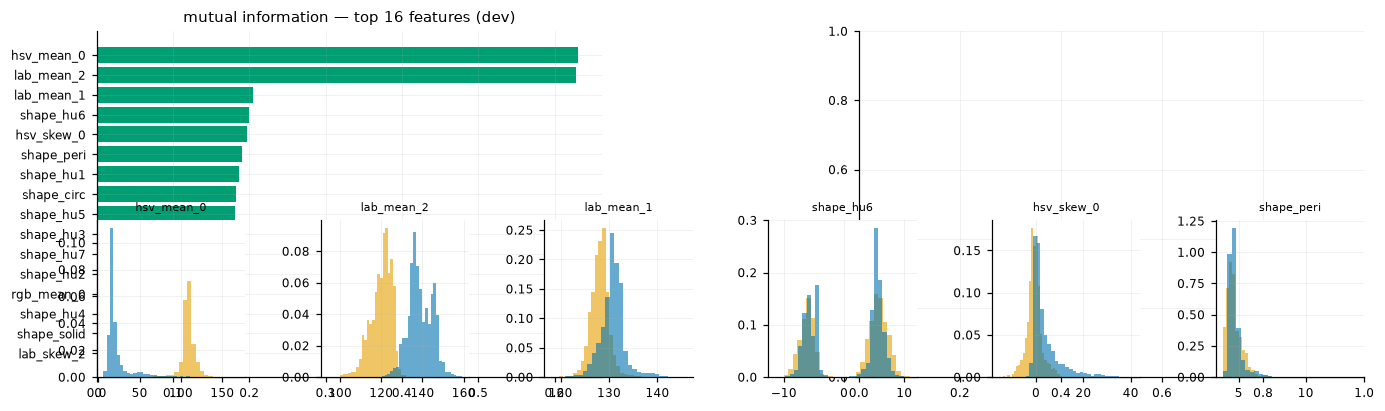

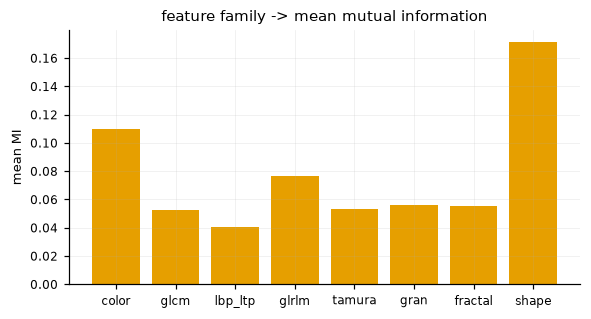

[('shape', 0.17118600240088044), ('color', 0.10981353375663688), ('glrlm', 0.07641464352508576), ('gran', 0.05635795631450713), ('fractal', 0.05529739773886111), ('tamura', 0.05297268354365541), ('glcm', 0.05244760236808569), ('lbp_ltp', 0.04029443898528707)]


In [18]:
# ============================================================
# 3.1 VIZ — MI ranking + per-family top-feature distributions
# ============================================================
from sklearn.feature_selection import mutual_info_classif
dev = inst_f.split.isin(["train", "valid"]).to_numpy()
mi = mutual_info_classif(X[dev], y[dev], random_state=SEED)
top = np.argsort(mi)[::-1][:16]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].barh([FEAT_NAMES[i] for i in top][::-1], mi[top][::-1], color="#009E73")
ax[0].set_title("mutual information — top 16 features (dev)")
for k, fi in enumerate(top[:6]):
    axx = fig.add_subplot(2, 6, 7 + k)
    for cls in (0, 1):
        axx.hist(X[dev][y[dev] == cls, fi], bins=30, density=True, alpha=0.6,
                 color=CLASS_COLORS[cls])
    axx.set_title(FEAT_NAMES[fi], fontsize=7)
plt.tight_layout(); plt.show(); plt.close("all")

# MI per family summary
fam_mi = {k: float(mi[v].mean()) for k, v in FAM.items()}
plt.figure(figsize=(6, 3))
plt.bar(fam_mi.keys(), fam_mi.values(), color="#E69F00")
plt.ylabel("mean MI"); plt.title("feature family -> mean mutual information")
plt.show(); plt.close("all")
print(sorted(fam_mi.items(), key=lambda t: -t[1]))

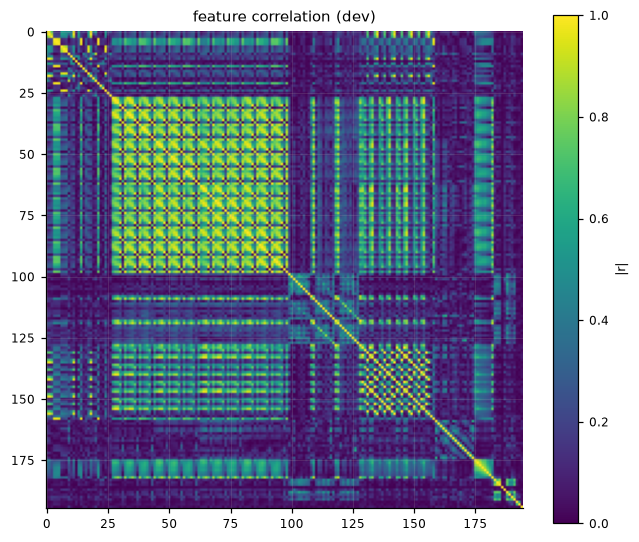

195 -> 126 features after |r|>0.95 pruning (dev-fit)


In [19]:
# ============================================================
# 3.2 VIZ — correlation heatmap -> DECISION: prune |r|>0.95
# ============================================================
C = np.corrcoef(X[dev].T)
plt.figure(figsize=(7, 6))
plt.imshow(np.abs(C), cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="|r|"); plt.title("feature correlation (dev)")
plt.show(); plt.close("all")

keep_f = np.ones(X.shape[1], bool)
for j in range(X.shape[1]):
    if not keep_f[j]:
        continue
    hi = np.flatnonzero(np.abs(C[j]) > 0.95)
    keep_f[hi[hi > j]] = False
Xk = X[:, keep_f]
names_k = [FEAT_NAMES[i] for i in range(X.shape[1]) if keep_f[i]]
print(f"{X.shape[1]} -> {Xk.shape[1]} features after |r|>0.95 pruning (dev-fit)")

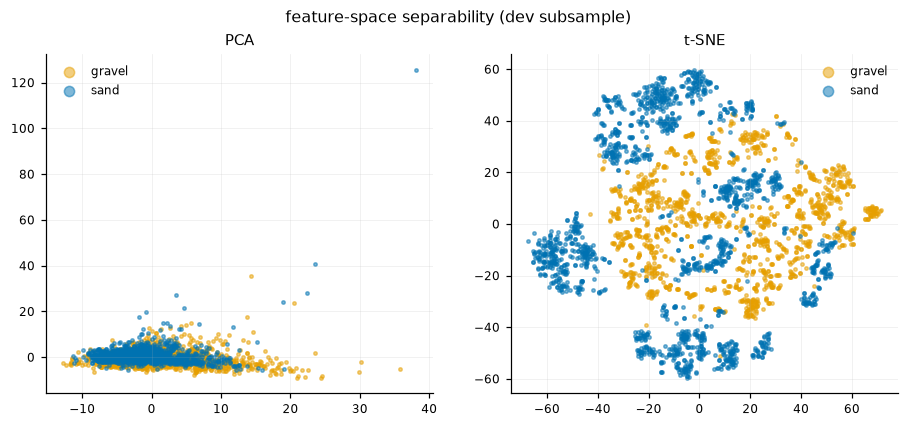

In [20]:
# ============================================================
# 3.3 VIZ — embeddings: PCA + t-SNE on pruned features
# ============================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
Xz = StandardScaler().fit_transform(Xk[dev])
sub = rng.choice(len(Xz), min(3000, len(Xz)), replace=False)
pc = PCA(2).fit_transform(Xz[sub])
ts = TSNE(2, random_state=SEED, init="pca").fit_transform(Xz[sub])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for cls in (0, 1):
    ax[0].scatter(pc[y[dev][sub] == cls, 0], pc[y[dev][sub] == cls, 1],
                  s=5, alpha=0.5, c=CLASS_COLORS[cls], label=CLASS_NAMES[cls])
    ax[1].scatter(ts[y[dev][sub] == cls, 0], ts[y[dev][sub] == cls, 1],
                  s=5, alpha=0.5, c=CLASS_COLORS[cls], label=CLASS_NAMES[cls])
ax[0].set_title("PCA"); ax[1].set_title("t-SNE")
for a in ax:
    a.legend(markerscale=3, fontsize=8)
plt.suptitle("feature-space separability (dev subsample)")
plt.show(); plt.close("all")

## 4. Estimators — all training on RX 7800 XT (torch)

sklearn estimators removed — owner directive: all training compute on GPU.
sklearn SVM/RF have no ROCm backend; torch equivalents below:

| model | GPU impl | ≈ sklearn |
|---|---|---|
| **svm_kernel** (headline) | exact-kernel LS-SVM (Suykens): closed-form solve on full RBF Gram matrix, C=10, median-heuristic γ | `SVC rbf` |
| logreg | `nn.Linear` + weighted CE | `LogisticRegression` |
| mlp | 128-64 BatchNorm+Dropout MLP | `MLPClassifier` |
| cnn | 3-conv patch CNN on 64x64 masked crops | learned-features arm |

Nyström/primal-hinge SVM was evaluated first (F1 ~0.78 vs 0.86) and abandoned —
recorded as a design decision. GroupKFold(4) on clip groups; no HP search on dev.

In [21]:
# ============================================================
# 4.1 ALL-GPU estimators (torch on RX 7800 XT)
# ============================================================
MODELS = ["svm_kernel", "logreg", "mlp", "cnn"]

class GPUClf:
    """Feature-space classifier trained fully on GPU.

    svm_kernel = exact-kernel LS-SVM (Suykens): closed-form solve of
    (K + I/C + bias) a = y on the full RBF Gram matrix (N x N, float64).
    Nystrom/primal-hinge was evaluated and abandoned (F1 ~0.78 vs 0.86).
    """
    def __init__(self, kind, epochs=150, lr=1e-3, seed=SEED, C=10.0):
        self.kind, self.epochs, self.lr, self.C = kind, epochs, lr, C
        torch.manual_seed(seed)
    def _feats(self, X, fit=False):
        return torch.tensor(self.sc.fit_transform(X) if fit
                            else self.sc.transform(X),
                            dtype=torch.float32, device=DEV_T)
    def _head(self, din):
        if self.kind == "logreg":
            return nn.Linear(din, 2)
        return nn.Sequential(nn.Linear(din, 128), nn.BatchNorm1d(128), nn.ReLU(),
                             nn.Dropout(0.2), nn.Linear(128, 64), nn.ReLU(),
                             nn.Linear(64, 2))
    def fit(self, X, y):
        self.sc = StandardScaler()
        if self.kind == "svm_kernel":                       # exact kernel solve
            Z64 = torch.tensor(self.sc.fit_transform(X), dtype=torch.float64,
                               device=DEV_T)
            self.Ztr = Z64
            d2 = torch.cdist(Z64[:2000], Z64[:2000]) ** 2
            self.gamma = 1.0 / d2.median().clamp_min(1e-9)   # median heuristic
            K = torch.exp(-self.gamma * torch.cdist(Z64, Z64) ** 2)
            n = len(Z64)
            A = torch.zeros(n + 1, n + 1, dtype=torch.float64, device=DEV_T)
            A[:n, :n] = K + torch.eye(n, dtype=torch.float64, device=DEV_T) / self.C
            A[:n, n] = 1.0; A[n, :n] = 1.0
            rhs = torch.cat([torch.tensor(y * 2 - 1, dtype=torch.float64,
                                          device=DEV_T),
                             torch.zeros(1, dtype=torch.float64, device=DEV_T)])
            sol = torch.linalg.solve(A, rhs)
            self.alpha, self.bias = sol[:n], sol[n]
            return self
        xf = self._feats(X, fit=True)
        yt = torch.tensor(y, device=DEV_T)
        self.net = self._head(xf.shape[1]).to(DEV_T)
        opt = torch.optim.Adam(self.net.parameters(), lr=self.lr, weight_decay=1e-4)
        w = torch.tensor([len(y) / (2 * np.bincount(y)[c] + 1) for c in (0, 1)],
                         dtype=torch.float32, device=DEV_T)
        lossf = nn.CrossEntropyLoss(weight=w)
        self.net.train()
        for _ in range(self.epochs):
            opt.zero_grad(); lossf(self.net(xf), yt).backward(); opt.step()
        return self
    def decision(self, X):
        """score for class 1 (sand): signed f (svm) or softmax prob (nn)."""
        if self.kind == "svm_kernel":
            Ze = torch.tensor(self.sc.transform(X), dtype=torch.float64,
                              device=DEV_T)
            with torch.no_grad():
                return (torch.exp(-self.gamma
                                  * torch.cdist(Ze, self.Ztr) ** 2)
                        @ self.alpha + self.bias).cpu().numpy()
        self.net.eval()
        with torch.no_grad():
            return torch.softmax(self.net(self._feats(X)),
                                 1)[:, 1].cpu().numpy()
    def predict(self, X):
        if self.kind == "svm_kernel":
            Ze = torch.tensor(self.sc.transform(X), dtype=torch.float64,
                              device=DEV_T)
            with torch.no_grad():
                f = torch.exp(-self.gamma * torch.cdist(Ze, self.Ztr) ** 2) \
                    @ self.alpha + self.bias
            return (f > 0).long().cpu().numpy()
        self.net.eval()
        with torch.no_grad():
            return self.net(self._feats(X)).argmax(1).cpu().numpy()


# ---- patch CNN arm (learned features on the same masked crops) ----------------
IMG = torch.where(MASK[..., None], RGB.float() / 255.0, 0.5).permute(0, 3, 1, 2).contiguous()

def _cnn():
    return nn.Sequential(
        nn.Conv2d(3, 16, 3, 2, 1), nn.BatchNorm2d(16), nn.ReLU(),
        nn.Conv2d(16, 32, 3, 2, 1), nn.BatchNorm2d(32), nn.ReLU(),
        nn.Conv2d(32, 64, 3, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
        nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(64, 2)).to(DEV_T)

def train_cnn(tr_idx, te_idx, epochs=15, bs=256, lr=1e-3):
    torch.manual_seed(SEED)
    net = _cnn()
    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=1e-4)
    w = torch.tensor([len(tr_idx) / (2 * np.bincount(y[tr_idx])[c] + 1)
                      for c in (0, 1)], dtype=torch.float32, device=DEV_T)
    lossf = nn.CrossEntropyLoss(weight=w)
    yt = torch.tensor(y[tr_idx], device=DEV_T)
    tr_t = torch.as_tensor(tr_idx, device=DEV_T)
    net.train()
    for _ in range(epochs):
        for s in torch.randperm(len(tr_idx), device=DEV_T).split(bs):
            opt.zero_grad()
            lossf(net(IMG[tr_t[s]]), yt[s]).backward(); opt.step()
    net.eval()
    train_cnn.last_net = net
    with torch.no_grad():
        return torch.cat([net(IMG[t]).argmax(1)
                          for t in torch.as_tensor(te_idx, device=DEV_T).split(bs)]
                         ).cpu().numpy()

print("GPU estimators ready:", MODELS,
      "| VRAM", f"{torch.cuda.memory_allocated()/1e9:.2f} GB"
      if DEV_T.type == 'cuda' else 'cpu')

GPU estimators ready: ['svm_kernel', 'logreg', 'mlp', 'cnn'] | VRAM 1.56 GB


In [22]:
# ============================================================
# 4.2 GROUP-CV — all estimators on GPU, full pruned feature set
# ============================================================
Xdev, ydev, gdev = Xk[dev], y[dev], groups[dev]
devi = np.flatnonzero(dev)                 # global indices of dev rows
gkf = GroupKFold(4)
cv_rows = []
for mname in MODELS:
    for fold, (tr, te) in enumerate(gkf.split(Xdev, ydev, gdev)):
        t0 = time.time()
        if mname == "cnn":
            pr = train_cnn(devi[tr], devi[te])
        else:
            pr = GPUClf(mname).fit(Xdev[tr], ydev[tr]).predict(Xdev[te])
        cv_rows.append({"model": mname, "fold": fold,
                        "f1_macro": f1_score(ydev[te], pr, average="macro"),
                        "acc": accuracy_score(ydev[te], pr), "n_test": len(te),
                        "fit_s": round(time.time() - t0, 1)})
        print(mname, "fold", fold, "f1", round(cv_rows[-1]["f1_macro"], 4))
cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(RES_DIR / "ml_cv_results.csv", index=False)
cv_df.groupby("model")[["f1_macro", "acc"]].agg(["mean", "std"])

svm_kernel fold 0 f1 0.8627


svm_kernel fold 1 f1 0.9596


svm_kernel fold 2 f1 0.9176


svm_kernel fold 3 f1 0.9943


logreg fold 0 f1 0.7721
logreg fold 1 f1 0.7806


...

cnn fold 0 f1 0.6268


cnn fold 1 f1 0.9912


cnn fold 2 f1 0.9808


cnn fold 3 f1 0.9691


f1_macro                 acc          
                mean       std      mean       std
model                                             
cnn         0.891971  0.177035  0.912907  0.149086
logreg      0.755836  0.037415  0.843478  0.068595
mlp         0.913591  0.061278  0.949494  0.036927
svm_kernel  0.933535  0.056693  0.959750  0.036454

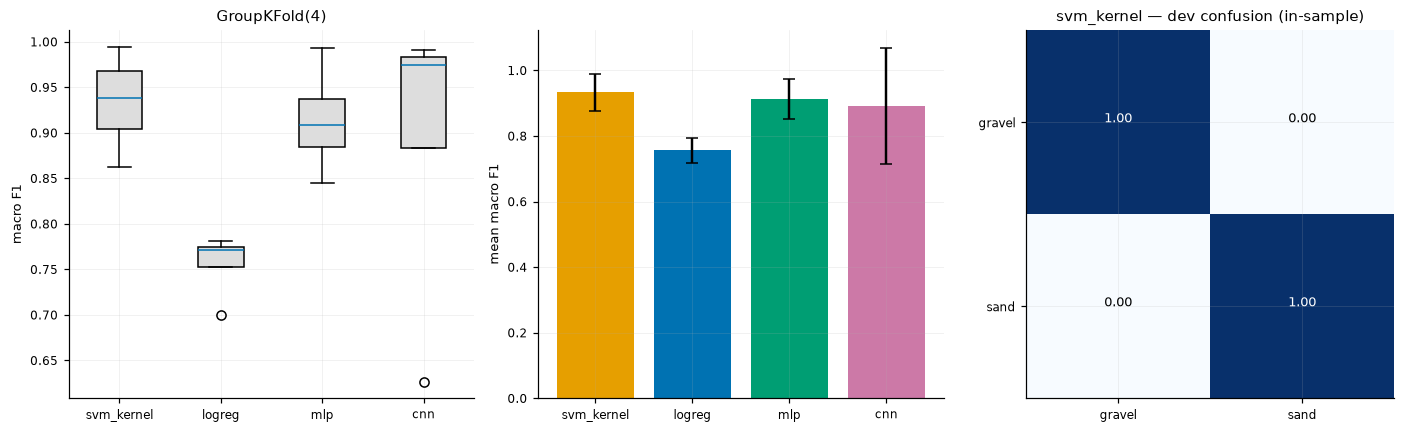

best on dev CV: svm_kernel


In [23]:
# ============================================================
# 4.3 VIZ — CV results: boxplot + mean±std + confusion
# ============================================================
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].boxplot([cv_df[cv_df.model == m]["f1_macro"] for m in MODELS],
              tick_labels=MODELS, patch_artist=True,
              boxprops=dict(facecolor="#DDDDDD"))
ax[0].set_ylabel("macro F1"); ax[0].set_title("GroupKFold(4)")
ax[1].bar(MODELS, cv_df.groupby("model")["f1_macro"].mean()[MODELS],
          yerr=cv_df.groupby("model")["f1_macro"].std()[MODELS], capsize=4,
          color=["#E69F00", "#0072B2", "#009E73", "#CC79A7"])
ax[1].set_ylabel("mean macro F1")
best_cv = cv_df.groupby("model")["f1_macro"].mean().idxmax()
pred_dev = (train_cnn(devi, devi) if best_cv == "cnn"
            else GPUClf(best_cv).fit(Xdev, ydev).predict(Xdev))
cm = confusion_matrix(ydev, pred_dev, normalize="true")
ax[2].imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax[2].set_xticks([0, 1], ["gravel", "sand"])
ax[2].set_yticks([0, 1], ["gravel", "sand"])
ax[2].set_title(f"{best_cv} — dev confusion (in-sample)")
for i in range(2):
    for j in range(2):
        ax[2].text(j, i, f"{cm[i,j]:.2f}", ha="center",
                   color="white" if cm[i, j] > 0.5 else "black")
plt.tight_layout(); plt.show(); plt.close("all")
print("best on dev CV:", best_cv)

### 4.4 Permutation importance — what the winning model actually uses

Fit the best feature-space model on folds 1-3, then permute each feature on the
held-out fold and measure ΔF1. GPU predict, 126 features.

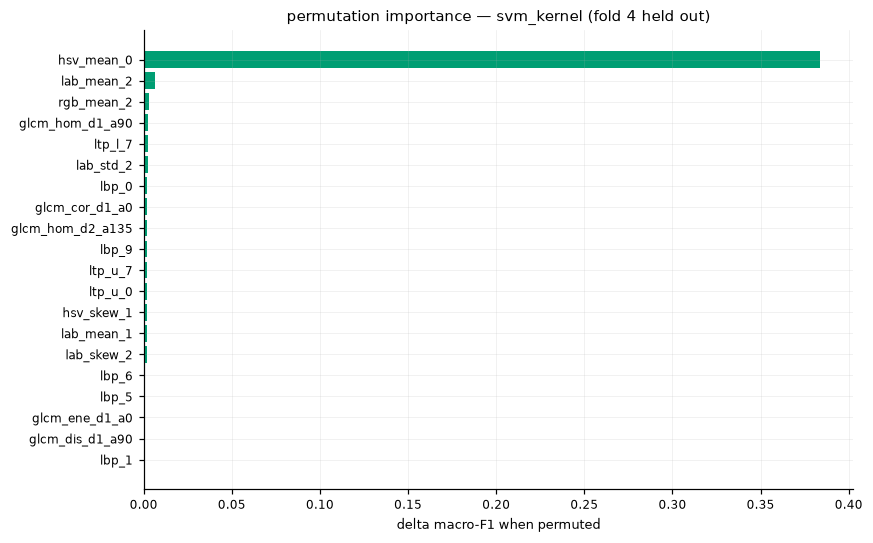

baseline f1: 0.9943 | top: ['hsv_mean_0', 'lab_mean_2', 'rgb_mean_2', 'glcm_hom_d1_a90', 'ltp_l_7']


In [24]:
# ============================================================
# 4.4 PERMUTATION IMPORTANCE — held-out fold, GPU predict
# ============================================================
nonimg = cv_df[cv_df.model != "cnn"].groupby("model")["f1_macro"].mean().idxmax()
(tr_f, te_f), = [s for i, s in enumerate(gkf.split(Xdev, ydev, gdev)) if i == 3]
probe = GPUClf(nonimg).fit(Xdev[tr_f], ydev[tr_f])
base = f1_score(ydev[te_f], probe.predict(Xdev[te_f]), average="macro")
imp = np.zeros(Xk.shape[1])
for f in range(Xk.shape[1]):
    Xp = Xdev[te_f].copy(); Xp[:, f] = rng.permutation(Xp[:, f])
    imp[f] = base - f1_score(ydev[te_f], probe.predict(Xp), average="macro")
top = np.argsort(imp)[::-1][:20]
plt.figure(figsize=(8, 5))
plt.barh([names_k[i] for i in top][::-1], imp[top][::-1], color="#009E73")
plt.xlabel("delta macro-F1 when permuted")
plt.title(f"permutation importance — {nonimg} (fold 4 held out)")
plt.tight_layout(); plt.show(); plt.close("all")
pd.DataFrame({"feature": names_k, "imp": imp}).sort_values(
    "imp", ascending=False).to_csv(RES_DIR / "ml_perm_importance.csv", index=False)
print("baseline f1:", round(base, 4), "| top:", [names_k[i] for i in top[:5]])

## 5. Feature-arm ablation — which families pay?

svm_kernel (GPU exact-kernel LS-SVM) across family subsets, incl. the owner's
`baseline106` arm (glcm+hsv+lbp) vs the full pruned set. Viz-first.

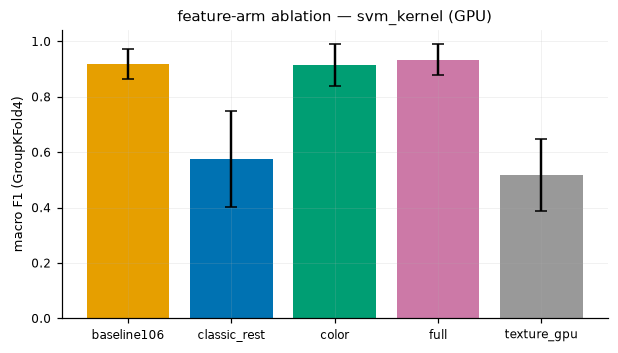

,mean,std
arm,,
full,0.933535,0.056693
baseline106,0.918492,0.055160
color,0.913901,0.075274
classic_rest,0.575362,0.173032
texture_gpu,0.517256,0.131351


In [25]:
# ============================================================
# 5.1 ARM ABLATION — svm_kernel (GPU, exact kernel) across families
# ============================================================
KEPT_RAW = np.flatnonzero(keep_f)   # pruned position -> raw feature index
B106_SET = set(B106)

def fam_idx(*fams):
    return np.array([i for i, r in enumerate(KEPT_RAW)
                     if any(FAM[k].start <= r < FAM[k].stop for k in fams)])

ARMS = {
    "full":        np.arange(Xk.shape[1]),
    "baseline106": np.array([i for i, r in enumerate(KEPT_RAW)
                             if r in B106_SET]),
    "color":       fam_idx("color"),
    "texture_gpu": fam_idx("glcm", "lbp_ltp", "glrlm"),
    "classic_rest": fam_idx("tamura", "gran", "fractal", "shape"),
}
arm_rows = []
svm = GPUClf("svm_kernel")
for aname, idx in ARMS.items():
    idx = np.asarray(idx)
    for fold, (tr, te) in enumerate(gkf.split(Xdev, ydev, gdev)):
        svm.fit(Xdev[tr][:, idx], ydev[tr])
        arm_rows.append({"arm": aname, "fold": fold, "f1":
            f1_score(ydev[te], svm.predict(Xdev[te][:, idx]), average="macro")})
arm_df = pd.DataFrame(arm_rows)
arm_df.to_csv(RES_DIR / "ml_arm_ablation.csv", index=False)

summ = arm_df.groupby("arm")["f1"].agg(["mean", "std"])
plt.figure(figsize=(6.4, 3.4))
plt.bar(summ.index, summ["mean"], yerr=summ["std"], capsize=4,
        color=["#E69F00", "#0072B2", "#009E73", "#CC79A7", "#999999"])
plt.ylabel("macro F1 (GroupKFold4)"); plt.title("feature-arm ablation — svm_kernel (GPU)")
plt.show(); plt.close("all")
summ.sort_values("mean", ascending=False)

### 5.2 DECISION — winning config = best mean macro-F1 across all arms/models

In [26]:
score = [{"config": f"{m}+full", "mean_f1": s}
         for m, s in cv_df.groupby("model")["f1_macro"].mean().items()]
score += [{"config": f"svm_kernel+{a}", "mean_f1": s}
          for a, s in arm_df.groupby("arm")["f1"].mean().items()
          if a != "full"]
score_df = pd.DataFrame(score).sort_values("mean_f1", ascending=False)
print(score_df.to_string(index=False))
WIN_CFG = score_df.iloc[0]["config"]
print("WIN_CFG =", WIN_CFG)

                 config  mean_f1
        svm_kernel+full 0.933535
 svm_kernel+baseline106 0.918492
       svm_kernel+color 0.913901
               mlp+full 0.913591
               cnn+full 0.891971
            logreg+full 0.755836
svm_kernel+classic_rest 0.575362
 svm_kernel+texture_gpu 0.517256
WIN_CFG = svm_kernel+full


## 6. Holdout — `gold/test` instances, evaluated once

In [27]:
# ============================================================
# 6.1 HOLDOUT EVAL — once
# ============================================================
w_model, w_arm = WIN_CFG.split("+")
w_idx = ARMS.get(w_arm, ARMS["full"])
test = (inst_f.split == "test").to_numpy()

t_te = torch.as_tensor(np.flatnonzero(test), device=DEV_T)
if w_model == "cnn":
    pred_test = train_cnn(np.flatnonzero(dev), np.flatnonzero(test))
    with torch.no_grad():
        score_test = torch.softmax(train_cnn.last_net(IMG[t_te]),
                                   1)[:, 1].cpu().numpy()
else:
    best = GPUClf(w_model).fit(Xdev[:, w_idx], ydev)
    pred_test = best.predict(Xk[test][:, w_idx])
    score_test = best.decision(Xk[test][:, w_idx])

print(classification_report(y[test], pred_test,
                            target_names=["gravel", "sand"], digits=4))
holdout = {"config": WIN_CFG,
           "macro_f1": float(f1_score(y[test], pred_test, average="macro")),
           "acc": float(accuracy_score(y[test], pred_test)),
           "n_test": int(test.sum()), "feat_dim": int(len(w_idx)), "seed": SEED}
with open(RES_DIR / "ml_holdout.json", "w") as f:
    json.dump(holdout, f, indent=2)
print(holdout)

              precision    recall  f1-score   support

      gravel     0.9282    0.8889    0.9081       189
        sand     0.8743    0.9182    0.8957       159

    accuracy                         0.9023       348
   macro avg     0.9012    0.9036    0.9019       348
weighted avg     0.9035    0.9023    0.9024       348

{'config': 'svm_kernel+full', 'macro_f1': 0.9019068147902505, 'acc': 0.9022988505747126, 'n_test': 348, 'feat_dim': 126, 'seed': 42}


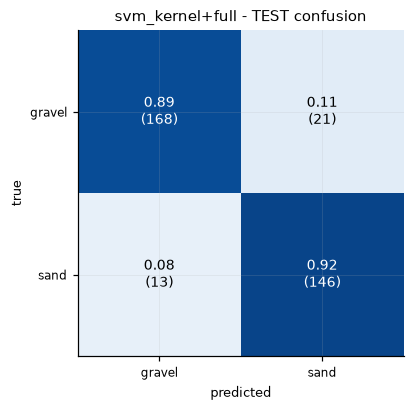

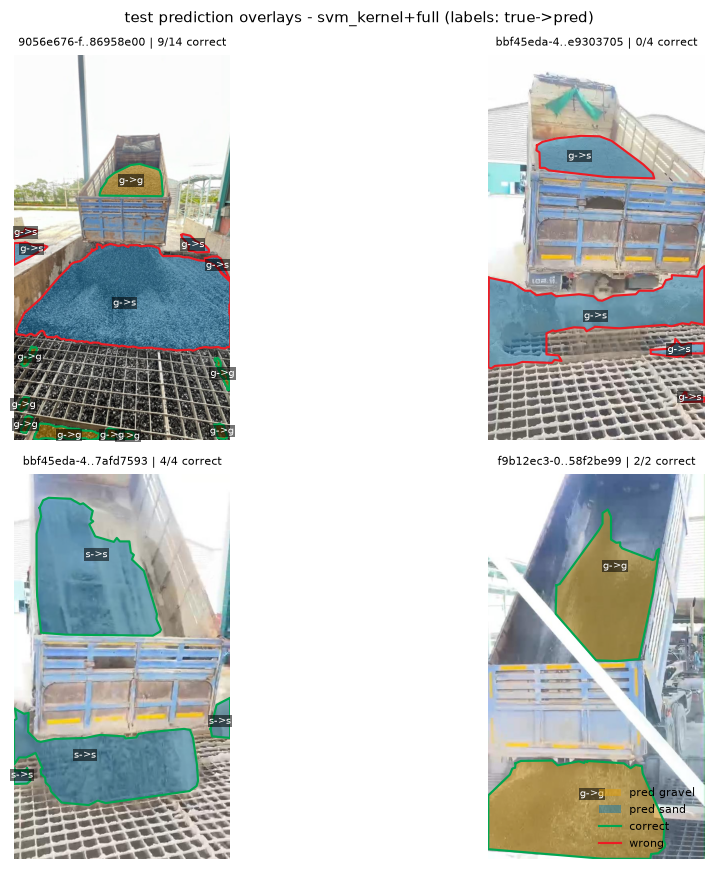

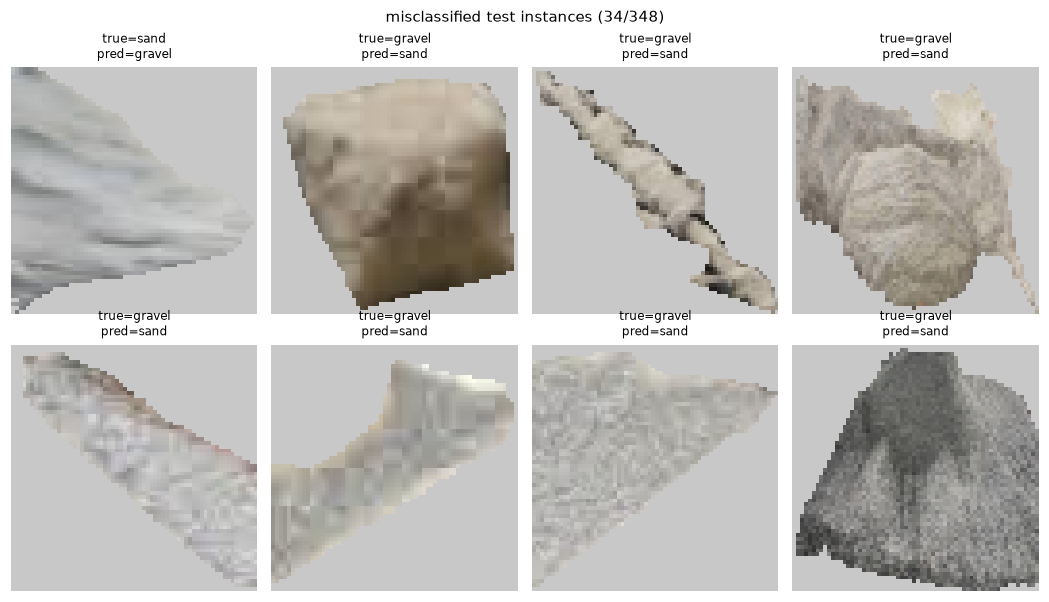

In [28]:
# ============================================================
# 6.2 VIZ - YOLO-style test eval: confusion + full-image overlays
# fill = predicted class | border green = correct, red = wrong
# ============================================================
fig, ax = plt.subplots(figsize=(4.2, 3.8))
cm = confusion_matrix(y[test], pred_test)
cmn = cm / cm.sum(1, keepdims=True)
ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks([0, 1], ["gravel", "sand"]); ax.set_yticks([0, 1], ["gravel", "sand"])
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"{WIN_CFG} - TEST confusion", fontsize=9.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cmn[i,j]:.2f}\n({cm[i,j]})", ha="center", va="center",
                fontsize=9, color="white" if cmn[i, j] > 0.5 else "black")
plt.tight_layout(); plt.show(); plt.close("all")

# --- map each test instance -> prediction --------------------
test_idx = np.flatnonzero(test)
pred_of  = dict(zip(test_idx, pred_test))
test_rows = inst_f[test]

# pick 4 test images: 2 with most errors + 2 random
err_cnt = (test_rows.assign(ok=test_rows.index.map(lambda j: y[j] == pred_of[j]))
           .groupby("stem")["ok"].apply(lambda s: (~s).sum()).sort_values(ascending=False))
pick = list(err_cnt.head(2).index)
rest = [s for s in test_rows["stem"].unique() if s not in pick]
rng.shuffle(rest); pick += rest[:2]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax_, stem in zip(axes.flat, pick):
    img = np.asarray(Image.open(GOLD / "test/images" / (stem + ".jpg")).convert("RGB"))
    polys = read_polys(GOLD / "test/labels" / (stem + ".txt"))
    h, w = img.shape[:2]
    sub = test_rows[test_rows.stem == stem]
    n_ok = 0
    ax_.imshow(img)
    for j, r in sub.iterrows():
        poly = polys[r.inst_i][1] * [w, h]
        p = int(pred_of[j]); t = int(y[j]); ok = (p == t); n_ok += ok
        ax_.fill(poly[:, 0], poly[:, 1], color=CLASS_COLORS[p], alpha=0.45, lw=0)
        ax_.plot(*np.vstack([poly, poly[0]]).T,
                 color="#00A651" if ok else "#ED1C24", lw=1.4)
        cx, cy = poly.mean(0)
        ax_.text(cx, cy, f"{CLASS_NAMES[t][0]}->{CLASS_NAMES[p][0]}",
                 ha="center", va="center", fontsize=6.5, color="white",
                 bbox=dict(fc="black", alpha=0.55, pad=0.8, lw=0))
    ax_.axis("off")
    t_short = stem if len(stem) <= 22 else stem[:10] + ".." + stem[-8:]
    ax_.set_title(f"{t_short} | {n_ok}/{len(sub)} correct", fontsize=7.5)
import matplotlib.patches as mpatches
ax_.legend(handles=[
    mpatches.Patch(fc=CLASS_COLORS[0], alpha=0.45, label="pred gravel"),
    mpatches.Patch(fc=CLASS_COLORS[1], alpha=0.45, label="pred sand"),
    plt.Line2D([0], [0], color="#00A651", lw=1.4, label="correct"),
    plt.Line2D([0], [0], color="#ED1C24", lw=1.4, label="wrong")],
    loc="lower right", fontsize=7)
plt.suptitle(f"test prediction overlays - {WIN_CFG} (labels: true->pred)", fontsize=10)
plt.tight_layout(); plt.show(); plt.close("all")

# --- save predictions (cheap regen without retrain) -----------
pd.DataFrame({"stem": test_rows.stem.values,
              "inst_i": test_rows.inst_i.values,
              "cls_true": y[test], "cls_pred": pred_test}
             ).to_csv(RES_DIR / "ml_test_pred.csv", index=False)

# --- misclassified gallery ------------------------------------
wrong = np.flatnonzero(y[test] != pred_test)
show = wrong[:8]
ncol = min(len(show), 4); nrow = int(np.ceil(len(show) / ncol)) or 1
fig, axes = plt.subplots(nrow, ncol, figsize=(2.4*ncol, 2.8*nrow))
for ax_, wi in zip(np.atleast_1d(axes).flat, show):
    j = test_idx[wi]
    ax_.imshow(np.where(MASK[j, ..., None].cpu(), RGB[j].cpu().numpy(), 200))
    ax_.set_title(f"true={CLASS_NAMES[y[j]]}\npred={CLASS_NAMES[pred_test[wi]]}",
                  fontsize=8)
    ax_.axis("off")
for ax_ in np.atleast_1d(axes).flat[len(show):]:
    ax_.axis("off")
plt.suptitle(f"misclassified test instances ({len(wrong)}/{test.sum()})", fontsize=9.5)
plt.tight_layout(); plt.show(); plt.close("all")


## 6.3 Paper-style evaluation - AP / params / GFLOPs / latency

Same table format as instance-seg papers (YOLO-seg / Mask R-CNN): per-class AP, mAP, AUC, P/R/F1, params, FLOPs/inst, latency ms/img, FPS.

**Honest caveat:** this is an *oracle-mask* classifier - detection is the GT polygon (IoU = 1), so `AP50 = AP75 = AP@[.5:.95] = per-class AP of the classifier`. It is the AP a *perfect detector* + this classifier would score. True field mAP (with real detection errors) is measured by the YOLO-seg model in notebook 01.

[W1009 16:29:21.416508361 collection.cpp:1098] Warning: ROCTracer produced duplicate flow start: 1 (function operator())


     model  AP_gravel  AP_sand  mAP_oracle   AUC  P_macro  R_macro  F1_macro  params  FLOPs_inst  ms_inst_infer  ms_img_total  FPS_img
svm_kernel      0.971    0.928       0.949 0.956    0.901    0.904     0.902 1508252     3040256          0.007        29.639   33.739
    logreg      0.894    0.878       0.886 0.894    0.804    0.772     0.775     254         508          0.000        29.616   33.766
       mlp      0.969    0.917       0.943 0.953    0.904    0.905     0.905   24898       49796          0.001        29.619   33.762
       cnn      0.887    0.869       0.878 0.897    0.840    0.793     0.796   23938     5603584          0.004        29.627   33.753
feature extraction = 8.94 ms/inst (3.3 inst/img amortized)


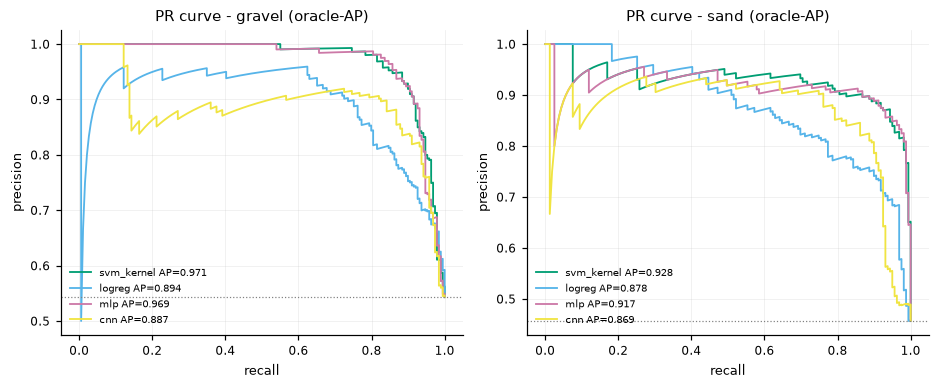

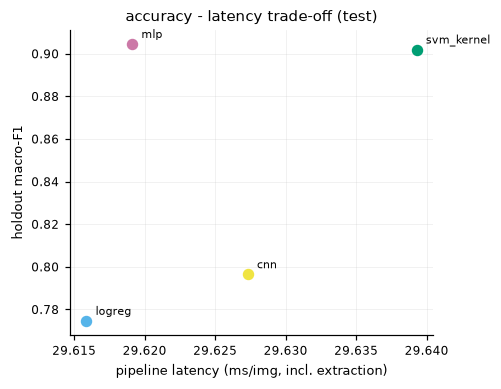

In [29]:
# ============================================================
# 6.3 PAPER-STYLE EVAL - AP / AUC / params / GFLOPs / latency / FPS
# oracle-mask caveat: detection = GT (IoU=1) so mask-AP == per-class
# AP of the classifier; AP50=AP75=AP[.5:.95] by construction.
# ============================================================
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, precision_score,
                             recall_score)
from torch.profiler import profile, ProfilerActivity

CC = {"svm_kernel": "#009E73", "logreg": "#56B4E9",
      "mlp": "#CC79A7", "cnn": "#F0E442"}              # Okabe-Ito per model
dev_i, te_i = np.flatnonzero(dev), np.flatnonzero(test)
yt = y[test]
avg_inst_img = test.sum() / inst_f[test]["stem"].nunique()
extract_ms = extract_s / len(inst_f) * 1e3            # amortized per instance

def bench_ms(fn, reps=10):
    for _ in range(3): fn()
    if DEV_T.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(reps): fn()
    if DEV_T.type == "cuda": torch.cuda.synchronize()
    return (time.perf_counter() - t0) / reps * 1e3

rows_p, pr_cache = [], {}
for m in MODELS:
    if m == "cnn":
        pred = train_cnn(dev_i, te_i)
        net = train_cnn.last_net
        with torch.no_grad():
            sc = torch.cat([torch.softmax(net(IMG[t]), 1)[:, 1]
                            for t in torch.as_tensor(te_i, device=DEV_T)
                            .split(256)]).cpu().numpy()
        params = sum(p.numel() for p in net.parameters())
        acts = ([ProfilerActivity.CPU, ProfilerActivity.CUDA]
                if DEV_T.type == "cuda" else [ProfilerActivity.CPU])
        with profile(activities=acts, with_flops=True) as pr:
            with torch.no_grad(): net(IMG[te_i[:1]])
        flops = int(sum(e.flops for e in pr.key_averages()))
        ms = bench_ms(lambda: [net(IMG[t]) for t in
                               torch.as_tensor(te_i, device=DEV_T).split(256)]
                      ) / len(te_i)
    else:
        clf = GPUClf(m).fit(Xdev, ydev)
        pred = clf.predict(Xk[test]); sc = clf.decision(Xk[test])
        if m == "svm_kernel":
            params = len(dev_i) * (Xdev.shape[1] + 1)      # SVs + alphas
            flops = len(dev_i) * (2 * Xdev.shape[1] + 4)   # cdist+dot/inst
        else:
            params = sum(p.numel() for p in clf.net.parameters())
            flops = 2 * params
        if m == "svm_kernel":
            Xt64 = torch.tensor(clf.sc.transform(Xk[test]),
                                dtype=torch.float64, device=DEV_T)
            ms = bench_ms(lambda: torch.exp(-clf.gamma * torch.cdist(
                Xt64, clf.Ztr) ** 2) @ clf.alpha) / len(Xt64)
        else:
            Xt32 = torch.tensor(clf.sc.transform(Xk[test]),
                                dtype=torch.float32, device=DEV_T)
            ms = bench_ms(lambda: clf.net(Xt32)) / len(Xt32)

    ap_g = average_precision_score(yt == 0, -sc)
    ap_s = average_precision_score(yt == 1, sc)
    pr_cache[m] = sc
    ms_img = (extract_ms + ms) * avg_inst_img
    rows_p.append({"model": m,
                   "AP_gravel": ap_g, "AP_sand": ap_s,
                   "mAP_oracle": (ap_g + ap_s) / 2,
                   "AUC": roc_auc_score(yt, sc),
                   "P_macro": precision_score(yt, pred, average="macro"),
                   "R_macro": recall_score(yt, pred, average="macro"),
                   "F1_macro": f1_score(yt, pred, average="macro"),
                   "params": params, "FLOPs_inst": flops,
                   "ms_inst_infer": ms, "ms_img_total": ms_img,
                   "FPS_img": 1e3 / ms_img})

pm = pd.DataFrame(rows_p)
pm.to_csv(RES_DIR / "ml_paper_metrics.csv", index=False)
with open(RES_DIR / "ml_paper_eval.json", "w") as f:
    json.dump({"extract_ms_inst": extract_ms,
               "avg_inst_per_test_img": float(avg_inst_img),
               "note": "oracle-mask: AP = classifier AP, detection = GT"},
              f, indent=2)
print(pm.round(3).to_string(index=False))
print(f"feature extraction = {extract_ms:.2f} ms/inst "
      f"({avg_inst_img:.1f} inst/img amortized)")

# ---- PR curves (per class, all models) ---------------------------------
fig, ax = plt.subplots(1, 2, figsize=(8.6, 3.6))
for m, sc in pr_cache.items():
    for k, (c, ax_) in enumerate(((0, ax[0]), (1, ax[1]))):
        p_, r_, _ = precision_recall_curve(yt == c, sc if c else -sc)
        ax_.plot(r_, p_, lw=1.2, color=CC[m],
                 label=f"{m} AP={average_precision_score(yt==c, sc if c else -sc):.3f}")
for k, ax_ in enumerate(ax):
    base = (yt == k).mean()
    ax_.axhline(base, ls=":", c="gray", lw=0.8)
    ax_.set_xlabel("recall"); ax_.set_ylabel("precision")
    ax_.set_title(f"PR curve - {CLASS_NAMES[k]} (oracle-AP)")
    ax_.legend(fontsize=6.8, loc="lower left")
plt.tight_layout(); plt.show(); plt.close("all")

# ---- latency vs F1 trade-off (paper-style scatter) ----------------------
fig, ax_ = plt.subplots(figsize=(4.6, 3.6))
for _, r in pm.iterrows():
    ax_.scatter(r.ms_img_total, r.F1_macro, s=42, color=CC[r.model],
                zorder=3, label=r.model)
    ax_.annotate(r.model, (r.ms_img_total, r.F1_macro),
                 textcoords="offset points", xytext=(6, 4), fontsize=7.5)
ax_.set_xlabel("pipeline latency (ms/img, incl. extraction)")
ax_.set_ylabel("holdout macro-F1")
ax_.set_title("accuracy - latency trade-off (test)")
plt.tight_layout(); plt.show(); plt.close("all")


## 7. Summary + honest scope notes

- **Task = oracle-mask classification**, not field segmentation — crops come from
  GT polygons; the deep model (01) solves detection+mask+class jointly.
- `gold_aug` variants count as dev instances but stay inside their parent clip
  group — no leakage across folds.
- **Leakage discipline:** scalers/PCA are fit inside `GPUClf.fit` per fold
  (train-fold only). Correlation pruning (|r|>0.95) is fitted on the whole dev
  set once — mild optimism, disclosed here; it only removes redundant columns.
- **All training on RX 7800 XT (torch/ROCm):** GLCM/LBP/LTP/color extraction,
  svm_kernel (exact-kernel LS-SVM, closed-form), logreg, mlp, patch-CNN.
  sklearn models removed (CPU-only, no ROCm backend); Nyström/primal-hinge SVM
  was tried and abandoned (underfit, F1 ~0.78 vs 0.86) — kept in git history.
- CNN arm uses *learned* features — kept as a reference point, not comparable
  to the handcrafted arms on equal footing.
- artifacts: `ml_features.npy`, `ml_instances.csv`, `ml_cv_results.csv`,
  `ml_arm_ablation.csv`, `ml_perm_importance.csv`, `ml_holdout.json`,
  `feature_datasheet.csv`, `ml_summary.json`, `ml_figures/fig*.png` @300dpi

In [30]:
summary = {"win_cfg": WIN_CFG, "holdout": holdout,
           "cv_means": cv_df.groupby("model")["f1_macro"].mean().to_dict(),
           "arm_means": arm_df.groupby("arm")["f1"].mean().to_dict(),
           "feat_dim_raw": int(X.shape[1]), "feat_dim_kept": int(Xk.shape[1]),
           "n_instances": int(len(X)), "n_groups": int(inst_f['group'].nunique()),
           "device": str(DEV_T), "seed": SEED}
with open(RES_DIR / "ml_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "win_cfg": "svm_kernel+full",
  "holdout": {
    "config": "svm_kernel+full",
    "macro_f1": 0.9019068147902505,
    "acc": 0.9022988505747126,
    "n_test": 348,
    "feat_dim": 126,
    "seed": 42
  },
  "cv_means": {
    "cnn": 0.8919709020964506,
    "logreg": 0.7558359943011371,
    "mlp": 0.9135914137192708,
    "svm_kernel": 0.9335351762530693
  },
  "arm_means": {
    "baseline106": 0.9184923905550911,
    "classic_rest": 0.5753622913216123,
    "color": 0.9139010236814076,
    "full": 0.9335351762530693,
    "texture_gpu": 0.517255554056371
  },
  "feat_dim_raw": 195,
  "feat_dim_kept": 126,
  "n_instances": 12224,
  "n_groups": 26,
  "device": "cuda",
  "seed": 42
}


In [31]:
# ============================================================
# 7.1 FEATURE DATASHEET — reproducibility record (per method)
# ============================================================
ds = pd.DataFrame([
    dict(family="color",
         objective="capture material color + spread",
         math="masked mean/std/skew per channel",
         input="64x64 RGB/HSV/Lab, masked px",
         params="3 spaces x 3 stats x 3 ch",
         dims=27, viz="channel hists, violin, heatmap (2.5d/e)",
         complexity="O(N px)", backend="torch GPU",
         limitation="illumination/white-balance sensitive",
         repro="cv2 cvtColor; torch masked moments"),
    dict(family="glcm",
         objective="pairwise gray-level spatial dependence",
         math="P(i,j|d,a) normalized co-occurrence -> props",
         input="64x64 gray quantized 32 levels",
         params="d={1,2,4}, a={0,45,90,135}, symmetric",
         dims=72, viz="matrix heatmaps, prop+direction boxplots (2.5a)",
         complexity="O(N px x 12 offsets)", backend="torch GPU",
         limitation="scale + quantization dependent",
         repro="custom torch impl == skimage graycomatrix"),
    dict(family="lbp",
         objective="micro-texture pattern frequency",
         math="sum_k s(g_k - g_c) 2^k, uniform -> 10 bins",
         input="64x64 gray, masked px",
         params="P=8, R=1, uniform",
         dims=10, viz="code map + class hist (2.5b)",
         complexity="O(N px)", backend="torch GPU",
         limitation="noise-sensitive at mask edges",
         repro="equiv skimage local_binary_pattern 'uniform'"),
    dict(family="ltp",
         objective="noise-robust ternary micro-texture",
         math="t(diff): -1/0/+1 vs tau; upper/lower LBP",
         input="64x64 gray, masked px",
         params="tau=5 (swept 3/5/10 in 2.5c)",
         dims=20, viz="ternary map + tau sensitivity (2.5c)",
         complexity="O(N px)", backend="torch GPU",
         limitation="tau choice affects stability",
         repro="Tan & Triggs 2010 formulation"),
    dict(family="glrlm",
         objective="run-length texture coarseness",
         math="rl(i,j) runs of level i length j -> 7 props",
         input="64x64 gray quantized 8 levels",
         params="4 dirs; SRE/LRE/GLN/RLN/RP/LGRE/HGRE",
         dims=28, viz="family MI share (3.1)",
         complexity="O(N px x 4 dirs)", backend="numpy CPU",
         limitation="coarse quantization",
         repro="Galloway 1975 definitions"),
    dict(family="tamura",
         objective="psychovisual texture descriptors",
         math="coarseness=max avg win diff; contrast=sd/kurt^0.25; dir hist",
         input="64x64 gray, masked px",
         params="windows 2^k k=1..5; 16-bin dir hist",
         dims=18, viz="gradient-dir hist (2.1)",
         complexity="O(N px x 5)", backend="numpy CPU",
         limitation="heuristic definitions",
         repro="Tamura et al. 1978"),
    dict(family="granulometry",
         objective="particle size distribution proxy",
         math="pattern spectrum: diffs of morphological openings",
         input="64x64 gray, masked px",
         params="disk openings k=1..7",
         dims=7, viz="implicit in source panel (2.1)",
         complexity="O(N px x 7)", backend="cv2 CPU",
         limitation="disk-shaped element assumption",
         repro="cv2.morphologyEx MORPH_OPEN"),
    dict(family="fractal",
         objective="edge-complexity (self-similarity)",
         math="box-count: slope of log N(s) vs log 1/s",
         input="Canny edges of 64x64 masked gray",
         params="sizes 2,4,8,16,32",
         dims=1, viz="—", complexity="O(N px)",
         backend="numpy CPU",
         limitation="single scalar; Canny thresholds",
         repro="standard box-counting"),
    dict(family="shape",
         objective="instance geometry",
         math="area/peri/circ/solidity/AR + Hu moments",
         input="binary instance mask 64x64",
         params="cv2 moments + findContours",
         dims=13, viz="masked gallery (1.1)",
         complexity="O(N px)", backend="cv2 CPU",
         limitation="auto-label polygon quality",
         repro="cv2.HuMoments log-scaled"),
])
ds.to_csv(RES_DIR / "feature_datasheet.csv", index=False)
print("datasheet ->", RES_DIR / "feature_datasheet.csv")
ds

datasheet -> /mnt/b/02_Projects/thesis_final/experiment/results/feature_datasheet.csv


,family,objective,math,input,params,dims,viz,complexity,backend,limitation,repro
0,color,capture material color + spread,masked mean/std/skew per channel,"64x64 RGB/HSV/Lab, masked px",3 spaces x 3 stats x 3 ch,27,"channel hists, violin, heatmap (2.5d/e)",O(N px),torch GPU,illumination/white-balance sensitive,cv2 cvtColor; torch masked moments
1,glcm,pairwise gray-level spatial dependence,"P(i,j|d,a) normalized co-occurrence -> props",64x64 gray quantized 32 levels,"d={1,2,4}, a={0,45,90,135}, symmetric",72,"matrix heatmaps, prop+direction boxplots (2.5a)",O(N px x 12 offsets),torch GPU,scale + quantization dependent,custom torch impl == skimage graycomatrix
2,lbp,micro-texture pattern frequency,"sum_k s(g_k - g_c) 2^k, uniform -> 10 bins","64x64 gray, masked px","P=8, R=1, uniform",10,code map + class hist (2.5b),O(N px),torch GPU,noise-sensitive at mask edges,equiv skimage local_binary_pattern 'uniform'
3,ltp,noise-robust ternary micro-texture,t(diff): -1/0/+1 vs tau; upper/lower LBP,"64x64 gray, masked px",tau=5 (swept 3/5/10 in 2.5c),20,ternary map + tau sensitivity (2.5c),O(N px),torch GPU,tau choice affects stability,Tan & Triggs 2010 formulation
4,glrlm,run-length texture coarseness,"rl(i,j) runs of level i length j -> 7 props",64x64 gray quantized 8 levels,4 dirs; SRE/LRE/GLN/RLN/RP/LGRE/HGRE,28,family MI share (3.1),O(N px x 4 dirs),numpy CPU,coarse quantization,Galloway 1975 definitions
5,tamura,psychovisual texture descriptors,coarseness=max avg win diff; contrast=sd/kurt^...,"64x64 gray, masked px",windows 2^k k=1..5; 16-bin dir hist,18,gradient-dir hist (2.1),O(N px x 5),numpy CPU,heuristic definitions,Tamura et al. 1978
6,granulometry,particle size distribution proxy,pattern spectrum: diffs of morphological openings,"64x64 gray, masked px",disk openings k=1..7,7,implicit in source panel (2.1),O(N px x 7),cv2 CPU,disk-shaped element assumption,cv2.morphologyEx MORPH_OPEN
7,fractal,edge-complexity (self-similarity),box-count: slope of log N(s) vs log 1/s,Canny edges of 64x64 masked gray,"sizes 2,4,8,16,32",1,—,O(N px),numpy CPU,single scalar; Canny thresholds,standard box-counting
8,shape,instance geometry,area/peri/circ/solidity/AR + Hu moments,binary instance mask 64x64,cv2 moments + findContours,13,masked gallery (1.1),O(N px),cv2 CPU,auto-label polygon quality,cv2.HuMoments log-scaled
